# 3. 使用教程

## 3.1 系统初始化

In [ ]:
pwd

In [1]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time, sleep
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "172.16.153.216"
qsync_ip = "172.16.153.216"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 1,
    "RefClock": "out",
    "DArate_S8-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "CaptureMode": 0,  # 0 只取第一组原始时域数据, 且只能在同步时候配置
    "INMixMode": 1,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC172.16.153.216开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.216 opened successfully
*********设备172.16.153.216开启成功*********
device_type: pqtm
backend_version: v2.11.4
ad_num: 4
da_num: 108
cpu_temp: nan
memory_use: 39.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S3-O1', 'S3-O2', 'S3-O3', 'S3-O4', 'S3-O5', 'S3-O6', 'S3-O7', 'S3-O8', 'S4-O1', 'S4-O2', 'S4-O3', 'S4-O4', 'S4-O5', 'S4-O6', 'S4-O7', 'S4-O8', 'S5-O1', 'S5-O2', 'S5-O3', 'S5-O4', 'S5-O5', 'S5-O6', 'S5-O7', 'S5-O8', 'S6-O1', 'S6-O2', 'S6-O3', 'S6-O4', 'S6-O5', 'S6-O6', 'S6-O7', 'S6-O8', 'S7-O1', 'S7-O2', 'S7-O3', 'S7-O4', 'S7-O5', 'S7-O6', 'S7-O7', 'S7-O8', 'S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S9-O5', 'S9-O6', 'S9-O7', 'S9-O8', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S14-O1', 'S14-O2', 'S14-

## 3.2 PQ-XY使用教程

### 3.2.1 控制波形播放

In [34]:
shots = 0xFFFFFFFF
period = 50e-6
ch = "S8-O1"

qsync.set("Shot", shots)
qsync.set("TrigPeriod", period)

freq = 0.43e9
t = 2e-6
delay = 75e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, round(t * DArate_xy))
std_sq2 = t / (4 * np.sqrt(np.log(2)))  # 2*FWHM
envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
wave = envelope * np.cos(2 * np.pi * freq * time_line)
wave = np.hstack(3 * (wave,))


device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

### 3.2.2 点频连续波模式

In [35]:
shots = 0xffffffff
freq = 0.43e9
amplitude = 1
t = 60e-6 # 波形时长
period = 50e-6 # trig周期，trig周期小于波形长度，连续波
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
wave = amplitude * np.cos(2 * np.pi * freq * time_line)

ch = "S8-O1"
qsync.set("TrigPeriod", period)
qsync.set("Shot", shots)
device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

### 3.2.3 播放延迟设置

In [37]:
ch = "S8-O1"
shots = 0xFFFFFFFF
period = 50e-6
qsync.set("Shot", shots)
device.set("Delay", 0, ch)  # 播放延迟为0
qsync.set("TrigPeriod", period)

freq = 0.43e9
t = 600e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)

device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

In [41]:
ch = "S8-O1"
shots = 0xFFFFFFFF
period = 50e-6
Delay = 64e-9  # 播放延迟为64ns

qsync.set("Shot", shots)
device.set("Delay", Delay, ch)
qsync.set("TrigPeriod", period)

freq = 0.43e9
t = 600e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
envelope = np.ones(round(t * DArate_xy))
wave = envelope * np.cos(2 * np.pi * freq * time_line)

device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

In [39]:
ch = "S11-O1"
shots = 0xFFFFFFFF
period = 50e-6
Delay = 79e-9

qsync.set("Shot", shots)
device.set("Delay", Delay, ch)
qsync.set("TrigPeriod", period)

freq = 0.43e9
t = 600e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
envelope = np.ones(round(t * DArate_xy))
wave = envelope * np.cos(2 * np.pi * freq * time_line)

device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

In [42]:
ch = "S8-O1"
shots = 0xffffffff
period = 50e-6
Delay = 80e-9

qsync.set("Shot", shots)
device.set("Delay", Delay, ch)
qsync.set("TrigPeriod", period)

freq = 0.43e9
t_d = 6e-9
time_line_d = np.linspace(0, t_d, round(t_d * DArate_xy), endpoint=False)
wave_d = np.zeros(round(t_d * DArate_xy))

t = 600e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
envelope = np.ones(round(t * DArate_xy))
wave = envelope * np.cos(2 * np.pi * freq * time_line)
wave = np.hstack((wave, wave_d))

device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

In [43]:
ch = "S8-O1"
shots = 0xFFFFFFFF
period = 50e-6
Delay = 64e-9

qsync.set("Shot", shots)
device.set("Delay", Delay, ch)
qsync.set("TrigPeriod", period)

freq = 4.3e9
t_d = 6e-9
time_line_d = np.linspace(0, t_d, round(t_d * DArate_xy), endpoint=False)
wave_d = np.zeros(round(t_d * DArate_xy))

t = 600e-9
time_line = np.linspace(0, t, round(t * DArate_xy), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
wave = np.hstack((wave_d, wave))

device.set("Waveform", wave, ch)
qsync.set("GenerateTrig")

In [83]:
qsync.set("ResetTrig")  # 停止生成触发

### 3.2.4 参数化波形

In [ ]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time, sleep
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

import waveforms as wf

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    # "DArate_S11-O1": DArate_xy,
    # "DArate_S9-O1": DArate_rd,
    "DArate_S6-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    "CaptureMode": 0,  # 0 只取第一组原始时域数据, 且只能在同步时候配置
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

device: None无法连接 timed out
*********QSYNC192.168.110.5开启成功*********
core_temp: 999℃
10M_locked: 0
qsync 192.168.110.5 opened successfully
*********设备192.168.110.5开启成功*********
device_type: pqtm
backend_version: v2.4.1-3-g6c935ca
ad_num: 0
da_num: 8
cpu_temp: 48.0
memory_use: 14.9
available chnl: 
OUT Chnl: ['S6-O1', 'S6-O2', 'S6-O3', 'S6-O4', 'S6-O5', 'S6-O6', 'S6-O7', 'S6-O8'] 

IN  Chnl: []
192.168.110.5开启成功
System synchronization succeeded


In [ ]:
# 生成三个连续的高斯包络信号，信号频率为3.5GHz
freq = 0.3e9
t = 400e-9
delay = 75e-9
# 生成半高宽固定的高斯包络
envelope = wf.gaussian(t) >> (delay + t / 2)
# 通过相乘，生成附加高斯包络的波形
wave = envelope * wf.cos(2 * wf.pi * freq)
# 通过移位相加，生成三段连续的高斯包络
wave = wave + (wave >> (t + delay)) + (wave >> 2 * (t + delay))
# 配置参数化信号的起始与终止时刻
wave.start = 0
wave.stop = 3 * (t + delay) + delay


# 向out1下发参数化波形对象
device.set("GenWave", wave, "S6-O1")

# 控制MC一直产生周期为200μs的触发信号
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("TrigPeriod", 300e-6)
qsync.set("GenerateTrig")

## 3.3 PQ-ZC使用教程

### 3.3.2 控制波形播放

In [82]:
wave_width = 75e-6
wave = np.ones(round(DArate_z * wave_width))
wave[-1] = 0

for ch in ["S11-O1", "S11-O2", "S11-O3", "S11-O4", "S11-O5", "S11-O6", "S11-O7", "S11-O8"]:
    device.set("Waveform", wave, ch)
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("GenerateTrig", 100e-6)

### 3.3.3 输出保持模式

In [ ]:
device.set("KeepAmp", 0)  
# device.set("KeepAmp", 1)
# device.set("KeepAmp", 2)

## 3.4 PQ-RD使用教程

### 3.4.1 读取下发激励

In [30]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time, sleep
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.26"
qsync_ip = "192.168.110.26"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 4e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    # "DArate_S11-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    # "DArate_S12-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1, # 4-6GHz选1, 6~8GHz选2
    "CaptureMode": 0,  # 0 只取第一组原始时域数据, 且只能在同步时候配置
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.26开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.26 opened successfully
*********设备192.168.110.26开启成功*********
device_type: pqtm
backend_version: v2.6.0-25-g18e8989
ad_num: 4
da_num: 4
cpu_temp: nan
memory_use: 13.4
available chnl: 
OUT Chnl: ['S9-O1', 'S9-O2', 'S9-O3', 'S9-O4'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.26开启成功
System synchronization succeeded


In [34]:
# device.set("CaptureMode", 1)
device.set("ShellCmd", "sudo reboot")

error: unpack requires a buffer of 20 bytes

In [29]:
out_ch = "S9-O1"
in_ch = "S9-I1"
shots = 1024
freq = 4.1e9
amplitude = 1
t = 2e-6
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = amplitude * np.cos(2 * np.pi * freq * time_line)

device.set("CaptureMode", 1)

device.set("PointNumber", 2e-6 * ADrate, in_ch)
qsync.set("TrigPeriod ", 500e-6)
device.set("Shot", shots)
qsync.set("Shot", shots)
device.set("Waveform", wave, out_ch)
device.set("StartCapture")
qsync.set("GenerateTrig")
import time
time.sleep(3)
data = device.get("TraceIQ", in_ch)

************<class 'nsqdriver.NS_MCI.Driver'>: 192.168.110.26************
*-*-*-*-*-*-*-远程函数报错: exception::RuntimeError -*-*-*-*-*-*-*-*
Traceback (most recent call last):
  File "/home/digilab/UltraMCI/backend/boards/mci_board.py", line 1043, in get_ad_waveform
    raise RuntimeError(f'异常: 接收触发数量不全, 当前已接收 {self.sig_fpga_trig_count}')
RuntimeError: 异常: 接收触发数量不全, 当前已接收 4098

da通道数: 4
ad通道数: 4
后台版本: v2.6.0-25-g18e8989
同步板温度: 50
-------固件版本: aa304726-------
RFS_ip: xdma://1, 核心温度: 59
RFS对应关系复查: (False, 9)
参考时钟来源: 内参考时钟
参考时钟锁定: 锁定
参考时钟: 未发生失锁
上次开启后接收触发数: 4098
INDelay: [0, 0, 0, 0, 0, 0, 0, 0]
当前ddr深度 64 Byte
进入ddr数据量 0 Byte
ddr流出数据量 0 Byte
*-*-*-*-*-*-*-远程函数报错: exception::RuntimeError -*-*-*-*-*-*-*-*


In [89]:
plt.plot(data.mean(axis=0))
plt.show()

In [26]:
data.shape

AttributeError: 'NoneType' object has no attribute 'shape'

### 3.4.2

### 3.4.3 解模数据的下发和获取

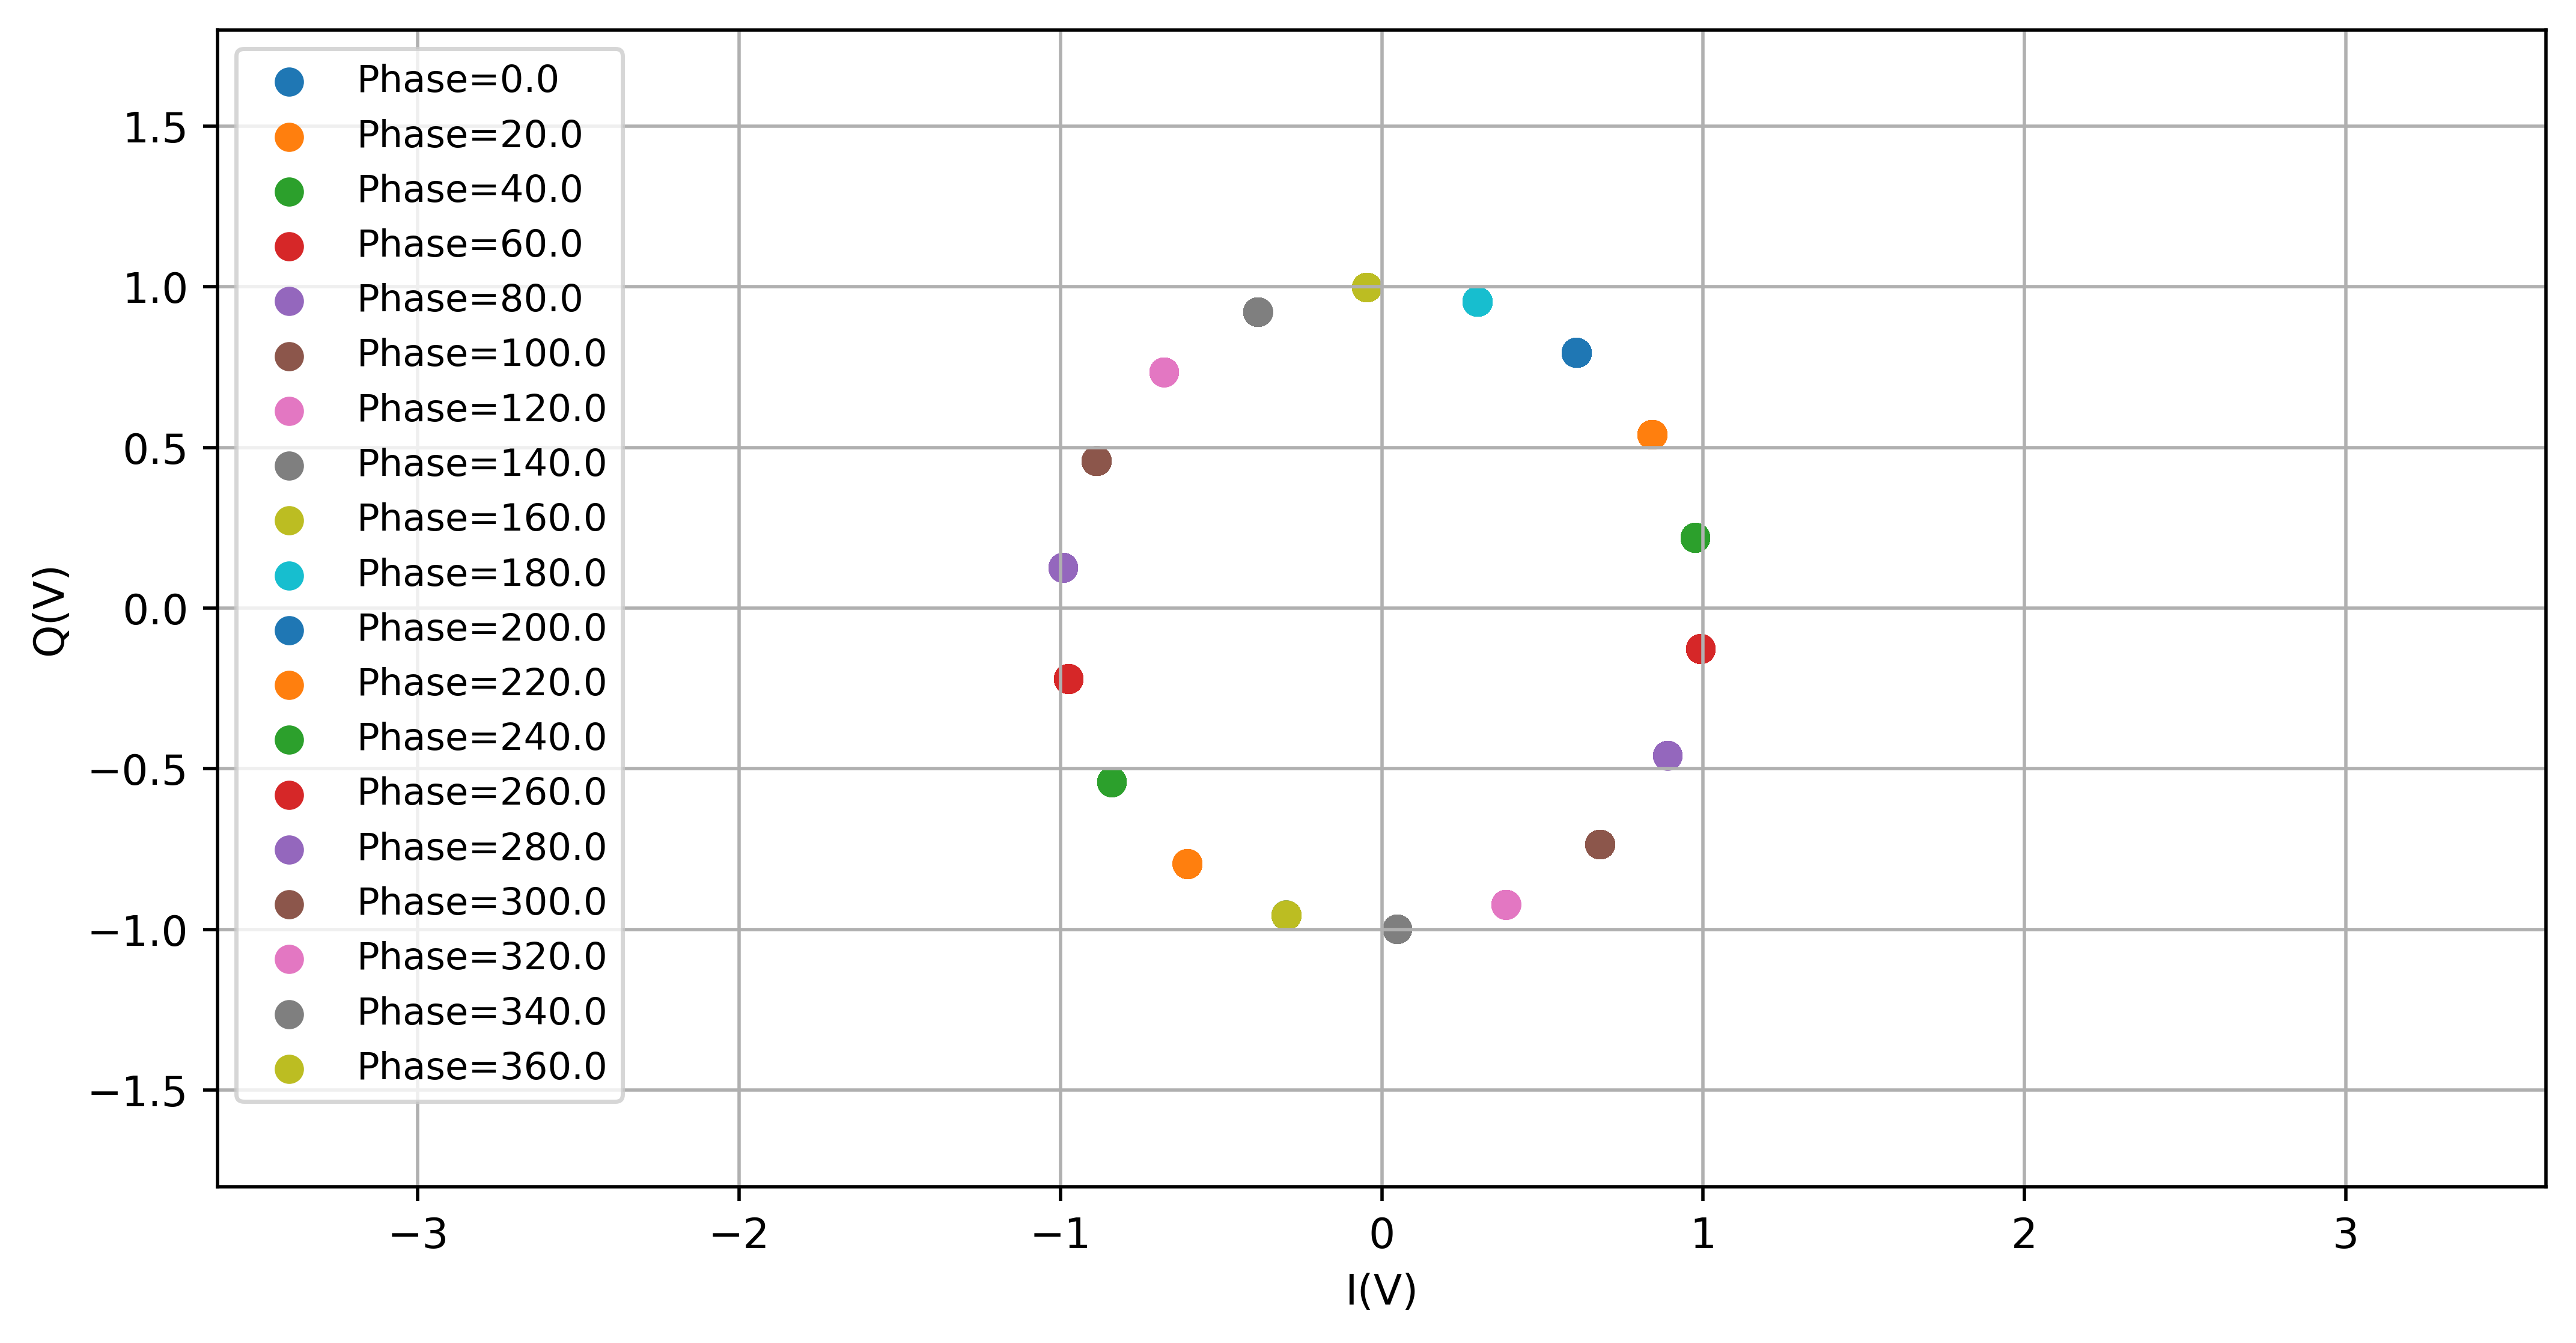

In [7]:
freq = 4.3e9  # out的信号频率
shots = 128
ch_O = "S9-O1"
ch_I = "S9-I1"
qsync.set("Shot", shots)
device.set("Shot", shots)
qsync.set("TrigPeriod", 50e-6)

phi = np.linspace(0, 360, 19)
rd_ch = 1
rd_width = 2e-6  # in通道采样时宽，2us
rd_delay = 410e-9
t = 4.6e-6
I = []
Q = []
phi_spectrum = []
device.set("CaptureMode", 0)
device.set("TimeWidth", rd_width, ch_I)
device.set("TriggerDelay", rd_delay, ch_I)
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
plt.figure(figsize=(10, 5), dpi=500)
for p in np.arange(len(phi)):
    wave = np.cos(2 * np.pi * freq * time_line + phi[p] * (np.pi / 180))
    device.set("Waveform", wave, ch_O)  # 波形下发
    device.set("FreqList", [float(freq)], ch_I)
    device.set("StartCapture")  # 通知in通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    phi_spectrum = device.get("IQ", ch_I)

    I = phi_spectrum.real
    Q = phi_spectrum.imag
    phi_spectrum_norm = [math.sqrt(i**2 + q**2) for i, q in zip(I, Q)]
    phi_spectrum = np.array([a / b for a, b in zip(phi_spectrum, phi_spectrum_norm)])
    phi_spectrum = phi_spectrum.T
    I = phi_spectrum.real
    Q = phi_spectrum.imag

    plt.scatter(I, Q, label=f"Phase={phi[p]}")
    plt.axis("equal")
    plt.ylabel("Q(V)")
    plt.xlabel("I(V)")
    plt.xlim(-5, 5)
    plt.ylim(-1.8, 1.8)
    plt.grid(True)
    plt.legend()

plt.legend(prop={"size": 9}, loc="upper left")
plt.show()

### 3.4.4 原始数据采集

In [17]:
# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.18"
qsync_ip = "192.168.110.18"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S8-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "CaptureMode": 1,  # 1 取shot组原始时域数据, 且只能在同步时候配置,
    "INMixMode": 1,
    # 后续若取解模结果， 需要配置为0，重新同步
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.18开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.18 opened successfully
*********设备192.168.110.18开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 43.0
memory_use: 22.9
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.18开启成功
System synchronization succeeded


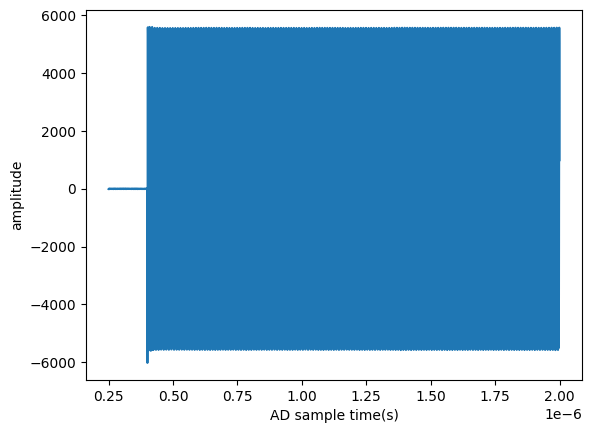

In [18]:
freq = 4.3e9
t = 4.8e-6
rd_width = 2e-6
capturemode = 1
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
ch_O = "S9-O1"
ch_I = "S9-I1"

device.set("CaptureMode", capturemode)
device.set("Shot", 1024)
qsync.set("Shot", 1024)
device.set("TriggerDelay", 0, ch_I)
qsync.set("TrigPeriod", 50e-6)
device.set("TimeWidth", rd_width, ch_I)
device.set("Waveform", wave, ch_O)
device.set("FreqList", [float(freq)], ch_I)
device.set("StartCapture")
qsync.set("GenerateTrig")
data = device.get("TraceIQ", ch_I)

time_line_data = np.linspace(0, rd_width, round(rd_width * ADrate), endpoint=False)
plt.plot(time_line_data[1000:], data.mean(axis=0)[1000:])
plt.ylabel("amplitude")
plt.xlabel("AD sample time(s)")
plt.show()

In [19]:
import waveforms as wf
# 生成三个连续的高斯包络信号，信号频率为3.5GHz
freq = 3.5e9
t = 200e-9
delay = 75e-9
# 生成半高宽固定的高斯包络
envelope = wf.gaussian(t) >> (delay + t / 2)
# 通过相乘，生成附加高斯包络的波形
wave = envelope * wf.cos(2 * wf.pi * freq)
# 通过移位相加，生成三段连续的高斯包络
wave = wave + (wave >> (t + delay)) + (wave >> 2 * (t + delay))
# 配置参数化信号的起始与终止时刻
wave.start = 0
wave.stop = 3 * (t + delay) + delay


# 向out1下发参数化波形对象
device.set("GenWave", wave, 1)

# 控制MC一直产生周期为200μs的触发信号
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("TrigPeriod", 200e-6)
qsync.set("GenerateTrig")

In [20]:
qsync.set("ResetTrig")

In [1]:
29.1 - 13.8

15.3

### 3.4.5 读取延迟配置

#### 3.4.5.1 读取延迟设置

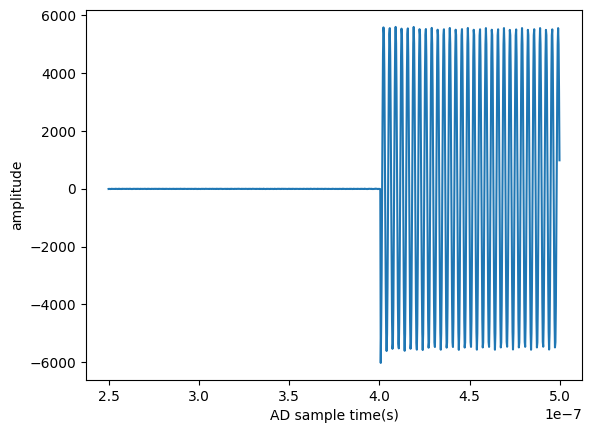

In [21]:
freq = 4.3e9
t = 4.8e-6
rd_width = 2e-6
in_delay = 0e-9  # 第二次运行修改为100e-9
capturemode = 1
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
ch_O = "S9-O1"
ch_I = "S9-I1"
device.set("Delay", 0, "all")

device.set("CaptureMode", capturemode)
device.set("Shot", 1024)
qsync.set("Shot", 1024)
device.set("TriggerDelay", in_delay, "all")
qsync.set("TrigPeriod", 50e-6)
device.set("TimeWidth", rd_width, "all")
device.set("Waveform", wave, ch_O)
device.set("FreqList", [float(freq)], ch_I)
device.set("StartCapture")
qsync.set("GenerateTrig")
data = device.get("TraceIQ", ch_I)

time_line_data = np.linspace(0, rd_width, round(rd_width * ADrate), endpoint=False)
plt.plot(time_line_data[1000:2000], data.mean(axis=0)[1000:2000])
plt.ylabel("amplitude")
plt.xlabel("AD sample time(s)")
plt.show()

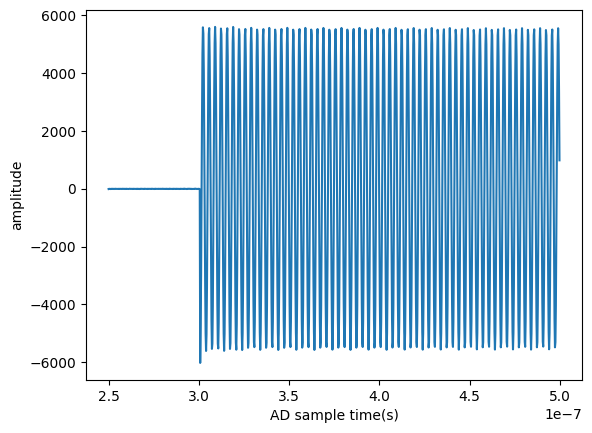

In [22]:
freq = 4.3e9
t = 4.8e-6
rd_width = 2e-6
in_delay = 100e-9  # 第二次运行修改为100e-9
capturemode = 1
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
ch_O = "S9-O1"
ch_I = "S9-I1"

device.set("CaptureMode", capturemode)
device.set("Shot", 1024)
qsync.set("Shot", 1024)
device.set("TriggerDelay", in_delay, "all")
qsync.set("TrigPeriod", 50e-6)
device.set("TimeWidth", rd_width, "all")
device.set("Waveform", wave, ch_O)
device.set("FreqList", [float(freq)], ch_I)
device.set("StartCapture")
qsync.set("GenerateTrig")
data = device.get("TraceIQ", ch_I)

time_line_data = np.linspace(0, rd_width, round(rd_width * ADrate), endpoint=False)
plt.plot(time_line_data[1000:2000], data.mean(axis=0)[1000:2000])
plt.ylabel("amplitude")
plt.xlabel("AD sample time(s)")
plt.show()

#### 3.4.5.2 读取延迟颗粒度

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[-0.29562604 -0.2957562  -0.2951248  ... -0.2962687  -0.29539305
  -0.29563913]] [[-0.95530367 -0.95526344 -0.95545876 ... -0.9551047  -0.95537585
  -0.9552997 ]]


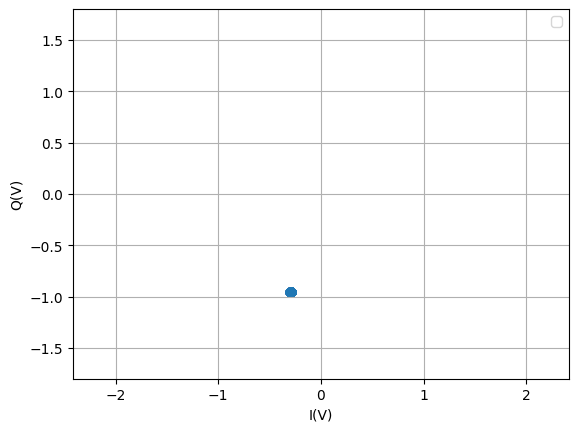

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[-0.69688725 -0.6970352  -0.69685024 ... -0.69675446 -0.69704264
  -0.6980715 ]] [[-0.7171807  -0.71703684 -0.7172167  ... -0.7173097  -0.7170296
  -0.7160281 ]]


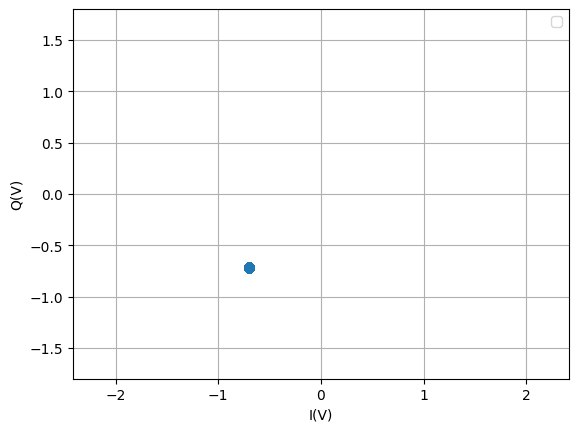

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[-0.9466072  -0.94679683 -0.9466143  ... -0.94669276 -0.9467804
  -0.94643027]] [[-0.32238942 -0.32183185 -0.3223681  ... -0.32213762 -0.32188028
  -0.32290837]]


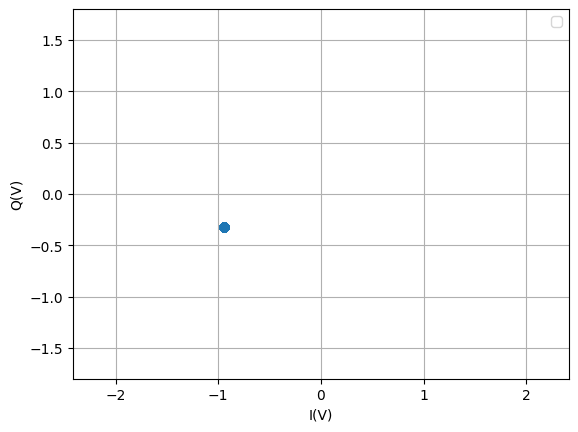

In [23]:
freq = 4.3e9
t = 4.8e-6
rd_width = 2e-6
rd_delay = np.linspace(0, 1/4e9*2, 3)
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
ch_O = "S9-O1"
ch_I = "S9-I1"
device.set("CaptureMode", 0)

plt.figure(1)
for idx, delay in enumerate(rd_delay):
    device.set("TriggerDelay", delay, ch_I)
    device.set("Shot", 1024)
    qsync.set("Shot", 1024)
    qsync.set("TrigPeriod", 50e-6)
    device.set("TimeWidth", rd_width, ch_I)
    device.set("Waveform", wave, ch_O)
    device.set("FreqList", [float(freq)], ch_I)
    device.set("StartCapture")
    qsync.set("GenerateTrig")
    data = device.get("IQ", ch_I)
    I = data.real
    Q = data.imag
    phi_spectrum_norm = [math.sqrt(i**2 + q**2) for i, q in zip(I, Q)]
    phi_spectrum = np.array([a / b for a, b in zip(data, phi_spectrum_norm)])
    phi_spectrum = phi_spectrum.T
    I = phi_spectrum.real
    Q = phi_spectrum.imag

    plt.scatter(I, Q)
    print(I, Q)
    plt.axis("equal")
    plt.ylabel("Q(V)")
    plt.xlabel("I(V)")
    plt.xlim(-5, 5)
    plt.ylim(-1.8, 1.8)
    plt.grid(True)
    plt.legend()
    plt.show()

#### 3.4.5.3 播放和采集信号相位匹配

In [27]:
# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.18"
qsync_ip = "192.168.110.18"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 6e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 1,
    "RefClock": "out",
    "DArate_S8-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    "CaptureMode": 0,  # 0 只取第一组原始时域数据, 且只能在同步时候配置
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.18开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.18 opened successfully
*********设备192.168.110.18开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 41.0
memory_use: 23.0
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.18开启成功
System synchronization succeeded


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


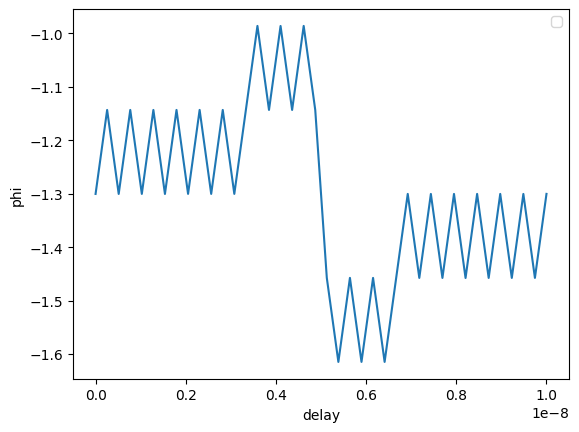

In [28]:
%matplotlib inline
capturemode = 0
freq = 0.3e9
t = 4.8e-6
rd_width = 2e-6
rd_delay = np.linspace(0, 10e-9, 40)
time_line = np.linspace(0, t, round(t * DArate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line + 0.5*np.pi)
ch_O = 'S9-O1'
ch_I = 'S9-I1'
device.set('CaptureMode', capturemode)
plt.figure(1)
phi_set = []
for idx, delay in enumerate(rd_delay):
    device.set('Delay', rd_delay[idx], ch_O)
    numofzero = (rd_delay[idx] - rd_delay[idx] // 16e-9 * 16e-9) * DArate_rd
    device.set('TriggerDelay', rd_delay[idx], ch_I)
    device.set('Shot', 1024)
    qsync.set('Shot', 1024)
    qsync.set('TrigPeriod', 50e-6)
    device.set('TimeWidth', rd_width, ch_I)
    device.set('Waveform', np.append(np.zeros(round(numofzero)), wave), ch_O)
    device.set('FreqList', [float(freq)], ch_I)
    device.set('StartCapture')
    qsync.set('GenerateTrig')
    data = device.get('IQ', ch_I)
    data = data.mean(axis=0)
    phi = np.angle(data)
    phi_set.append(phi)
plt.plot(rd_delay, phi_set)
# plt.plot(rd_delay, [phi_set[0]]*len(phi_set), label = f'播放波形相位')
plt.ylabel('phi')
plt.xlabel('delay')
plt.legend()
plt.show()  

# 4. 表征实验

##  4.1 S21

In [1]:
# 用这个
import numpy as np
import matplotlib.pyplot as plt
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
SHARED_DEVICE_MEM.clear_ip()
import time
# from tqdm.notebook import tqdm
from tqdm import tqdm

deviceIP = "192.168.110.29"
qsync_ip = "192.168.110.29"
device = MCIDriver(deviceIP, 10)
qsync = QSYNCDriver(qsync_ip)
DArate_rd = 8e9
DArate_xy = 6e9
DArate_xy = 8e9
DArate_z = 4e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S5-O1": DArate_rd,
    # "DArate_S8-O1": DArate_xy,
    # "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 2, # 4到6G用1，6到8G用2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)
# 设置参数


*********QSYNC192.168.110.29开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.29 opened successfully
*********设备192.168.110.29开启成功*********
device_type: pqtm
backend_version: v2.9.4-37-g4ccf7f7
ad_num: 1
da_num: 7
cpu_temp: nan
memory_use: 17.4
available chnl: 
OUT Chnl: ['S5-O1', 'S5-O2', 'S5-O3', 'S5-O4', 'S5-O5', 'S5-O6', 'S5-O7'] 

IN  Chnl: ['S5-I1']
192.168.110.29开启成功
System synchronization succeeded


In [2]:
CONFIG = {
    "PROBE_FREQ": 6.74340e9,
    "PROBE_AMP": 0.018
}

In [3]:
# S21 的
# 设置参数
%matplotlib qt5
in_ch = "S5-I1"
out_ch = "S5-O1"
delta = 0.002e9 
freq_range = np.linspace(CONFIG['PROBE_FREQ'] - delta, CONFIG['PROBE_FREQ'] + delta, 101)
wave_width = 4e-6
wave_amp = CONFIG['PROBE_AMP']
shots = 1024
device.set("CaptureMode", 0)
# device.set("capturemode")
time_line = np.linspace(0, wave_width, round(wave_width * DArate_rd), endpoint=False)
device.set("Shot", shots)  # 设置设备需要接受的shot数量
qsync.set("Shot", shots)  # 设置 qsync 发出的触发数量
qsync.set("TrigPeriod", 70e-6)  # 设置 qsync 的触发周期
device.set("TrigDelay", 200e-9)
device.set("TimeWidth", 2e-6, in_ch)  # 设置 IN 通道采样时宽

# 开始按频点扫描
s21_res = []
for freq in tqdm(freq_range):
    wave = wave_amp * np.cos(2 * np.pi * freq * time_line)
    device.set("Waveform", wave, out_ch)  # 将波形下发到对应 OUT 通道
    device.set("FreqList", [float(freq)], in_ch)  # 配置对应 IN 通道解模的频点
    # print(freq)
    device.set("StartCapture")  # 通知 IN 通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号，总共的触发数量为Shot个
    iq = device.get("IQData", in_ch)
    # print(iq.mean(axis=0))
    s21_res.append(iq)  # 获取硬解数据
s21_res = np.array(s21_res).mean(axis=1)
s21_power = 20 * np.log10(np.abs(s21_res))
plt.grid()
plt.plot(freq_range, s21_power)
plt.show()

100%|██████████| 101/101 [00:12<00:00,  8.24it/s]


In [168]:
%matplotlib qt5
plt.grid()
plt.plot(freq_range, s21_power)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (61,) and (101, 1)

## 4.2 S21 vs Power

In [154]:
# import numpy as np
# import time
# import matplotlib.pyplot as plt
# from tqdm.notebook import tqdm 
# from nsqdriver import MCIDriver, QSYNCDriver
# from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
# SHARED_DEVICE_MEM.clear_ip()

# deviceIP = "192.168.110.18"
# qsync_ip = "192.168.110.18"
# driver = MCIDriver(deviceIP, 10)
# qsync = QSYNCDriver(qsync_ip)
# DArate_rd = 8e9
# DArate_xy = 6e9
# DArate_z = 4e9
# ADrate = 4e9
# sysparam = {
#     "MixMode": 2,
#     "RefClock": "out",
#     "DArate_S9-O1": DArate_rd,
#     "DArate_S8-O1": DArate_xy,
#     "DArate_S11-O1": DArate_z,
#     "ADrate": ADrate,
#     "INMixMode": 2,
#     "CaptureMode": 0,
# }
# qsync_param = {"TrigFrom": 0, "RefClock": "in"}
# qsync.open(system_parameter=qsync_param)
# driver.open(system_parameter=sysparam)
# qsync.sync_system()
# time.sleep(2)
# # 设置参数
in_ch = "S9-I1"
out_ch = "S9-O1"
freq_num = 61
delta = 0.0018e9
freq_range = np.linspace(CONFIG['PROBE_FREQ'] - delta, CONFIG['PROBE_FREQ'] + delta, freq_num)
power_num = 14
power_range = np.linspace(0.001, 0.2, power_num)
wave_width = 6e-6
shots = 512
time_line = np.linspace(0, wave_width, round(wave_width * DArate_rd), endpoint=False)
device.set('Shot', shots) # 设置设备需要接受的shot数量
qsync.set('Shot', shots) # 设置 qsync 生成触发数量
qsync.set('TrigPeriod', 50e-6) # 设置 qsync 生成触发信号周期
device.set('TimeWidth', 2e-6, in_ch) # 设置 IN 通道采样时宽
s21_vs_power = []
# 开始按频点扫描
for freq in tqdm(freq_range):
    # 按功率扫描
    s21_res = []
    for power in power_range:
        wave = power * np.cos(2*np.pi*freq*time_line)
        device.set('Waveform', wave, out_ch) # 将波形下发到对应 OUT 通道
        device.set('FreqList', [float(freq)], in_ch) # 配置对应IN 硬解频点
        device.set('StartCapture') # 通知 IN 通道开启采集
        qsync.set('GenerateTrig') # 生成触发信号
        s21_res.append(device.get('IQData', in_ch)) # 获取硬解数据
    s21_vs_power.append(s21_res)
s21_vs_power = np.array(s21_vs_power).mean(axis=2)
s21_vs_power = 20*np.log10(np.abs(s21_vs_power))[:, :, 0]
# 归一化
s21_vs_power = (s21_vs_power.T-s21_vs_power.mean(axis=1))/(s21_vs_power.max(axis=1)-s21_vs_power.min(axis=1))
plt.imshow(s21_vs_power)
plt.xticks(list(range(freq_range.size))[::freq_num//10], freq_range[::freq_num//10]/1e9)
plt.yticks(list(range(power_range.size))[::power_num//10], np.around(power_range[::power_num//10],decimals=2 ))
plt.colorbar()
plt.show()

  0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 61/61 [01:47<00:00,  1.77s/it]


In [153]:
plt.imshow(s21_vs_power)
plt.xticks(list(range(freq_range.size))[::freq_num//10], freq_range[::freq_num//10]/1e9)
plt.yticks(list(range(power_range.size))[::power_num//10], np.around(power_range[::power_num//10],decimals=2 ))
plt.colorbar()
plt.show()

## 4.3 Spectrum

In [221]:
xy_ch = "S8-O1"  # drive xy使用OUT1通道
drive_width = 500e-9
xy_amp = CONFIG["XY_AMP"]
probe_out_ch = "S9-O1"
probe_in_ch = "S9-I1"
probe_delay = 200e-9
probe_freq = CONFIG['PROBE_FREQ']
probe_width = 4e-6
probe_amp = CONFIG['PROBE_AMP']
shots = 1024 * 2
time_line = np.linspace(0, probe_width, round(probe_width * DArate_rd), endpoint=False)
device.set("Shot", shots)  # 设置IN通道硬解运行次数
out_delay = (drive_width // 16e-9) * 16e-9 # 计算probe的outdelay 粒度16ns
zero_num = round((drive_width - out_delay) * DArate_rd)  # 计算余数中要补充的0的个数
wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
# # 将probe波形向后延迟drive_width的长度
wave = np.hstack([np.zeros(zero_num), wave])
device.set("OUTDelay", out_delay + 00e-9, probe_out_ch)  # 设置probe的outdelay 粒度16ns
device.set("Waveform", wave, probe_out_ch)  # 将波形下发到对应OUT通道
device.set("TimeWidth", probe_width, probe_in_ch)  # 设置IN通道采样时宽
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # 配置对应IN硬解频点
device.set("INDelay", probe_delay + drive_width, probe_in_ch)
qsync.set("Shot", shots)  # 设置qsync生成触发数量
qsync.set("TrigPeriod", 60e-6)  # 设置qsync生成触发信号周期
time_line = np.linspace(0, drive_width, round(drive_width * DArate_xy), endpoint=False)
delta = 0.1e9
freq_range = np.linspace(CONFIG['XY_FREQ'] - delta, CONFIG['XY_FREQ'] + delta, 61) #3.815
# 开始按频点扫描
specrum_res = []
for freq in tqdm(freq_range):
    wave = xy_amp * np.cos(2 * np.pi * freq * time_line)
    device.set("Waveform", wave, xy_ch)  # 将波形下发到对应OUT通道
    device.set("StartCapture")  # 通知IN通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    specrum_res.append(device.get("IQData", probe_in_ch))  # 获取硬解数据
specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(freq_range, specrum_power)
plt.show()

100%|██████████| 61/61 [00:11<00:00,  5.33it/s]


In [223]:
CONFIG.update({
    'XY_AMP': 0.018,
    'XY_FREQ': 4.866e9
})

In [222]:
plt.grid()
plt.plot(freq_range, specrum_power)
plt.show()

## 4.4 Spectrum vs Flux

In [253]:
# import numpy as np
# import matplotlib.pyplot as plt
# from nsqdriver import MCIDriver, QSYNCDriver
# from tqdm.notebook import tqdm
# import time

# SHARED_DEVICE_MEM.clear_ip()

# deviceIP = "192.168.110.18"
# qsync_ip = "192.168.110.18"
# driver = MCIDriver(deviceIP, 10)
# qsync = QSYNCDriver(qsync_ip)
# DArate_rd = 6e9
# DArate_xy = 6e9
# DArate_z = 2e9
# ADrate = 4e9
# sysparam = {
#     "MixMode": 2,
#     "RefClock": "out",
#     "DArate_S9-O1": DArate_rd,
#     "DArate_S8-O1": DArate_xy,
#     "DArate_S11-O1": DArate_z,
#     "ADrate": ADrate,
#     "INMixMode": 1,
#     "CaptureMode": 0,
# }
# qsync_param = {"TrigFrom": 0, "RefClock": "in"}
# qsync.open(system_parameter=qsync_param)
# driver.open(system_parameter=sysparam)
# qsync.sync_system()
# time.sleep(2)
# 设置参数
xy_ch = 'S8-O1'               # drive xy使用OUT3通道
drive_width = CONFIG["XY_WIDTH"]
xy_amp = CONFIG['XY_AMP']

z_ch = 'S11-O1'
probe_bias = 0        # 读取时使用的偏置值

probe_ch_in = 'S9-I1'            # probe使用IN1 OUT1通道
probe_ch_out = 'S9-O1'
probe_delay = 400e-9
probe_freq = CONFIG['PROBE_FREQ']
probe_width = 2e-6
probe_amp = CONFIG['PROBE_AMP']
shots = 512
time_line = np.linspace(0, probe_width, round(probe_width*DArate_rd), endpoint=False)

device.set('Shot', shots)                                  # 设置IN通道硬解运行次数
out_delay = drive_width // 16e-9 * 16e-9  # 计算probe的outdelay 粒度16ns
zero_num = round((drive_width - out_delay) * DArate_rd)  # 计算余数中要补充的0的个数
wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
wave = np.hstack([np.zeros(zero_num), wave])
device.set("OUTDelay", out_delay, probe_out_ch)  # 设置probe的outdelay 粒度16ns
# device.set("OUTDelay", 48e-9, xy_ch)  # 设置probe的outdelay 粒度16ns
device.set("Waveform", wave, probe_ch_out)  # 将波形下发到对应OUT通道
device.set('TimeWidth', probe_width, probe_ch_in)             # 设置IN通道采样时宽
device.set('FreqList', [float(probe_freq)], probe_ch_in)      # 配置对应IN硬解频点
device.set('INDelay', probe_delay + drive_width, probe_ch_in)
qsync.set('Shot', shots)                                # 设置qsync生成触发数量
qsync.set('TrigPeriod', 80e-6)                         # 设置qsync生成触发信号周期

time_line = np.linspace(0, drive_width, round(drive_width*DArate_xy), endpoint=False)

delta = 0.05e9
freq_num = 61
bias_num = 21
freq_range = np.linspace(CONFIG['XY_FREQ'] - delta - delta/2, CONFIG['XY_FREQ'] + delta, freq_num) #3.815
bias_range = np.linspace(-0.12, 0.12, 21)

# 开始扫描bias
spectrum_vs_flux = []
for bias in tqdm(bias_range):
    _z = bias*np.ones((int(drive_width * DArate_z),))
    _probe = probe_bias * np.ones((int(probe_width * DArate_z),))
    wave_z = np.hstack((_z, _probe))
    device.set("Waveform", wave_z, z_ch)  # 将波形下发到对应OUT通道
    # 开始按频点扫描
    spectrum_res = []
    for freq in freq_range:
        wave = xy_amp * np.cos(2*np.pi*freq*time_line)
        device.set('Waveform', wave, xy_ch)                    # 将波形下发到对应OUT通道
        device.set('StartCapture')                             # 通知IN通道开启采集
        qsync.set('GenerateTrig')                           # 生成触发信号
        spectrum_res.append(device.get('IQData', probe_ch_in))    # 获取硬解数据
    spectrum_vs_flux.append(spectrum_res)

spectrum_vs_flux = np.array(spectrum_vs_flux).mean(axis=2)
spectrum_vs_flux = 20*np.log10(np.abs(spectrum_vs_flux))[:, :, 0]
# 归一化
spectrum_vs_flux = (spectrum_vs_flux.T-spectrum_vs_flux.mean(axis=1))/(spectrum_vs_flux.max(axis=1)-spectrum_vs_flux.min(axis=1))
plt.imshow(spectrum_vs_flux.T)
plt.xticks(list(range(freq_range.size))[::freq_num//10], freq_range[::freq_num//10]/1e9)
plt.yticks(list(range(bias_range.size))[::bias_num//10], np.around(bias_range[::bias_num//10],decimals=2 ))
plt.colorbar()
plt.show()

100%|██████████| 21/21 [01:54<00:00,  5.47s/it]


In [251]:
plt.imshow(spectrum_vs_flux.T)
freq_num = 61
bias_num = 21
plt.xticks(list(range(freq_range.size))[::freq_num//10], freq_range[::freq_num//10]/1e9)
plt.yticks(list(range(bias_range.size))[::bias_num//10], np.around(bias_range[::bias_num//10],decimals=2 ))
plt.colorbar()
plt.show()

In [256]:
CONFIG

{'PROBE_FREQ': 6743400000.0,
 'PROBE_AMP': 0.018,
 'XY_AMP': 0.0247,
 'XY_FREQ': 4866000000.0,
 'Z_DRIVER_BIAS': 0.0,
 'XY_WIDTH': 3.41e-08}

In [255]:
CONFIG.update({"Z_DRIVER_BIAS": 0.0})

## 4.5 Power Rabi

In [226]:
# # 用这个
# import numpy as np
# import matplotlib.pyplot as plt
# from nsqdriver import MCIDriver, QSYNCDriver

# SHARED_DEVICE_MEM.clear_ip()

# deviceIP = "192.168.110.18"
# qsync_ip = "192.168.110.18"
# driver = MCIDriver(deviceIP, 10)
# qsync = QSYNCDriver(qsync_ip)
# DArate_rd = 8e9
# DArate_xy = 6e9
# DArate_z = 4e9
# ADrate = 4e9
# sysparam = {
#     "MixMode": 2,
#     "RefClock": "out",
#     "DArate_S9-O1": DArate_rd,
#     "DArate_S8-O1": DArate_xy,
#     "DArate_S11-O1": DArate_z,
#     "ADrate": ADrate,
#     "INMixMode": 2,
#     "CaptureMode": 0,
# }
# qsync_param = {"TrigFrom": 0, "RefClock": "in"}
# qsync.open(system_parameter=qsync_param)
# driver.open(system_parameter=sysparam)
# qsync.sync_system()

# time.sleep(2)

# 设置参数
xy_ch = "S8-O1"  # drive xy使用OUT3通道
drive_width = 200e-9
probe_out_ch = "S9-O1"
probe_in_ch = "S9-I1"
z_ch = "S11-O1"
probe_delay = 200e-9
probe_freq = CONFIG["PROBE_FREQ"]
xy_freq = CONFIG['XY_FREQ']
probe_width = 4e-6
probe_amp = CONFIG['PROBE_AMP']
shots = 1024 * 2
bias = CONFIG['Z_DRIVER_BIAS']
probe_bias = 0

time_line = np.linspace(0, probe_width, round(probe_width * DArate_rd), endpoint=False)
device.set("Shot", shots)  # 设置IN通道硬解运行次数
out_delay = drive_width // 16e-9 * 16e-9  # 计算probe的outdelay 粒度16ns
zero_num = round((drive_width - out_delay) * DArate_rd)  # 计算余数中要补充的0的个数
wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
# # 将probe波形向后延迟drive_width的长度
wave = np.hstack([np.zeros(zero_num), wave])
device.set("OUTDelay", out_delay, probe_out_ch)  # 设置probe的outdelay 粒度16ns
device.set("Waveform", wave, probe_out_ch)  # 将波形下发到对应OUT通道
device.set("TimeWidth", probe_width, probe_in_ch)  # 设置IN通道采样时宽
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # 配置对应IN硬解频点
device.set("INDelay", probe_delay + drive_width, probe_in_ch)
qsync.set("Shot", shots)  # 设置qsync生成触发数量
qsync.set("TrigPeriod", 80e-6)  # 设置qsync生成触发信号周期
time_line = np.linspace(0, drive_width, round(drive_width * DArate_xy), endpoint=False)

_z = bias * np.ones((round(drive_width * DArate_z),))
_probe = probe_bias * np.ones((round(probe_width * DArate_z),))
wave_z = np.hstack((_z, _probe))
# device.set("Waveform", wave_z, z_ch)  # 将波形下发到对应OUT通道

power_range = np.linspace(0.001, 0.15, 51)
# 开始按power扫描
specrum_res = []
for xy_amp in tqdm(power_range):
    wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
    device.set("Waveform", wave, xy_ch)  # 将波形下发到对应OUT通道
    device.set("StartCapture")  # 通知IN通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    specrum_res.append(device.get("IQData", probe_in_ch))  # 获取硬解数据
specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(power_range, specrum_power)
plt.show()

100%|██████████| 51/51 [00:11<00:00,  4.58it/s]


In [257]:
CONFIG

{'PROBE_FREQ': 6743400000.0,
 'PROBE_AMP': 0.018,
 'XY_AMP': 0.0247,
 'XY_FREQ': 4866000000.0,
 'Z_DRIVER_BIAS': 0.0,
 'XY_WIDTH': 3.41e-08}

In [179]:
plt.plot(power_range, specrum_power)
plt.show()

In [227]:
CONFIG.update({"XY_AMP": 0.0247})

## 4.6 Time Rabi

In [233]:
xy_ch = "S8-O1"  # drive xy使用OUT3通道
probe_out_ch = "S9-O1"
probe_in_ch = "S9-I1"
z_ch = "S11-O1"
probe_delay = 200e-9
probe_freq = CONFIG['PROBE_FREQ']
xy_freq = CONFIG['XY_FREQ']
probe_width = 4e-6
probe_amp = CONFIG['PROBE_AMP']
shots = 1024 * 2
bias = 0.6
probe_bias = -0.1
xy_amp = CONFIG['XY_AMP']

device.set("Shot", shots)  # 设置IN通道硬解运行次数

device.set("TimeWidth", probe_width, probe_in_ch)  # 设置IN通道采样时宽
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # 配置对应IN硬解频点
qsync.set("Shot", shots)  # 设置qsync生成触发数量
qsync.set("TrigPeriod", 200e-6)  # 设置qsync生成触发信号周期

time_range = np.linspace(1e-9, 200e-9, 61)
# 开始按power扫描
specrum_res = []
for drive_width in tqdm(time_range):

    time_line = np.linspace(0, drive_width, round(drive_width * DArate_xy), endpoint=False)
    wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
    device.set("Waveform", wave, xy_ch)  # 将波形下发到对应OUT通道

    # 重新计算probe 的波形延迟
    time_line = np.linspace(0, probe_width, round(probe_width * DArate_rd), endpoint=False)
    out_delay = drive_width // 16e-9 * 16e-9  # 计算probe的outdelay 粒度16ns
    zero_num = round((drive_width - out_delay) * DArate_rd)  # 计算余数中要补充的0的个数
    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
    # # 将probe波形向后延迟drive_width的长度
    wave = np.hstack([np.zeros(zero_num), wave])
    device.set("OUTDelay", out_delay, probe_out_ch)  # 设置probe的outdelay 粒度16ns
    device.set("Waveform", wave, probe_out_ch)  # 将波形下发到对应OUT通道

    # 计算probe的采集时刻
    device.set("INDelay", out_delay + probe_delay, probe_in_ch)

    # # 重新计算z的播放长度
    # _z = bias * np.ones((int(drive_width * DArate_z),))
    # _probe = probe_bias * np.ones((int(probe_width * DArate_z),))
    # wave_z = np.hstack((_z, _probe))
    # device.set("Waveform", wave_z, z_ch)  # 将波形下发到对应OUT通道

    device.set("StartCapture")  # 通知IN通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    specrum_res.append(device.get("IQData", probe_in_ch))  # 获取硬解数据
specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.grid()
plt.plot(time_range, specrum_power)
plt.show()


100%|██████████| 61/61 [00:30<00:00,  1.99it/s]


In [26]:
plt.plot(time_range, specrum_power)
plt.show()

In [258]:
CONFIG

{'PROBE_FREQ': 6743400000.0,
 'PROBE_AMP': 0.018,
 'XY_AMP': 0.0247,
 'XY_FREQ': 4866000000.0,
 'Z_DRIVER_BIAS': 0.0,
 'XY_WIDTH': 3.41e-08}

In [235]:
CONFIG.update({"XY_WIDTH": 34.1e-9})

## 4.7 T1

In [236]:
# xy 和probe之间的距离

# import numpy as np
# import matplotlib.pyplot as plt
# from nsqdriver import MCIDriver, QSYNCDriver

# SHARED_DEVICE_MEM.clear_ip()

# deviceIP = "192.168.110.18"
# qsync_ip = "192.168.110.18"
# driver = MCIDriver(deviceIP, 10)
# qsync = QSYNCDriver(qsync_ip)
# DArate_rd = 6e9
# DArate_xy = 6e9
# DArate_z = 4e9
# ADrate = 4e9
# sysparam = {
#     "MixMode": 2,
#     "RefClock": "out",
#     "DArate_S9-O1": DArate_rd,
#     "DArate_S8-O1": DArate_xy,
#     "DArate_S11-O1": DArate_z,
#     "ADrate": ADrate,
#     "INMixMode": 1,
#     "CaptureMode": 0,
# }
# qsync_param = {"RefClock": "in"}
# qsync.open(system_parameter=qsync_param)
# driver.open(system_parameter=sysparam)
# qsync.sync_system()
# time.sleep(2)
# 设置参数
xy_ch = "S8-O1"  # drive xy使用OUT3通道
probe_out_ch = "S9-O1"
probe_in_ch = "S9-I1"
z_ch = "S11-O1"
probe_delay = 150e-9
probe_freq = CONFIG['PROBE_FREQ']
xy_freq = CONFIG['XY_FREQ']
xy_amp = CONFIG['XY_AMP']
probe_width = 4e-6
probe_amp = CONFIG['PROBE_AMP']
shots = 1024  * 2
bias = 0.6
probe_bias = -0.1
drive_width = CONFIG['XY_WIDTH']

time_line = np.linspace(0, probe_width, round(probe_width * DArate_rd), endpoint=False)
device.set("Shot", shots)  # 设置IN通道硬解运行次数

device.set("TimeWidth", probe_width, probe_in_ch)  # 设置IN通道采样时宽
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # 配置对应IN硬解频点
device.set("INDelay", probe_delay + drive_width, probe_in_ch)
qsync.set("Shot", shots)  # 设置qsync生成触发数量
qsync.set("TrigPeriod", 280e-6)  # 设置qsync生成触发信号周期

# 计算xy的播放
time_line = np.linspace(
    0, drive_width, round(drive_width * DArate_xy), endpoint=False
)
wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
device.set("Waveform", wave, xy_ch)  # 将波形下发到对应OUT通道

time_range = np.linspace(1e-6, 200e-6, 61)
# 开始按power扫描
specrum_res = []
for xy_probe_width in tqdm(time_range):

    # 计算probe的播放
    out_delay = (drive_width + xy_probe_width) // 16e-9 * 16e-9  # 计算probe的outdelay 粒度16ns
    zero_num = round(
        (drive_width + xy_probe_width - out_delay) * DArate_rd
    )  # 计算余数中要补充的0的个数
    time_line = np.linspace(
        0, probe_width, round(probe_width * DArate_rd), endpoint=False
    )
    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
    # # 将probe波形向后延迟drive_width的长度
    wave = np.hstack([np.zeros(zero_num), wave])
    # print(out_delay + , "probe")
    # print(drive_width + xy_probe_width + probe_delay, "probe in delay")
    device.set("OUTDelay", out_delay, probe_out_ch)  # 设置probe的outdelay 粒度16ns
    device.set("Waveform", wave, probe_out_ch)  # 将波形下发到对应OUT通道

    # 计算probe的采集时刻
    device.set("INDelay", drive_width + xy_probe_width + probe_delay, probe_in_ch)

    # 计算z的播放
    # _z = bias * np.ones((int(drive_width * DArate_z),))
    # _probe = probe_bias * np.ones((int(probe_width * DArate_z),))
    # wave_z = np.hstack((_z, _probe))
    # device.set("Waveform", wave_z, z_ch)  # 将波形下发到对应OUT通道

    device.set("StartCapture")  # 通知IN通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    specrum_res.append(device.get("IQData", probe_in_ch))  # 获取硬解数据
specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()

100%|██████████| 61/61 [00:39<00:00,  1.54it/s]


In [29]:
plt.plot(time_range, specrum_power)
plt.show()

In [238]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import csv
from datetime import date
import os



sample_name = "sample-id158-4"  # 请替换为实际的样品名称

def exponential_decay(t, A, T1, B):
    """
    Exponential decay function for T1 fitting.
    
    Parameters:
    t : array
        Time points
    A : float
        Initial amplitude
    T1 : float
        Decay time constant
    B : float
        Offset
    
    Returns:
    array : Exponential decay values
    """
    return A * np.exp(-t / T1) + B

# 使用实际数据
t = time_range / 1e-6  # 原始时间数据，单位转换为μs
y_noisy = specrum_power.reshape(-1)

# 执行拟合
popt, pcov = curve_fit(exponential_decay, t, y_noisy, p0=[1.0, 10.0, 0.0])

# 提取拟合参数
fitted_A, fitted_T1, fitted_B = popt

# 生成拟合曲线
y_fit = exponential_decay(t, fitted_A, fitted_T1, fitted_B)

# 绘制结果
plt.figure(figsize=(10, 6))
plt.scatter(t, y_noisy, label='Raw Data')
plt.plot(t, y_fit, 'r-', label='Fitted Curve')
plt.xlabel('Time (μs)')
plt.ylabel('Signal')
plt.legend()
plt.title(f'T1 Fit: T1 = {fitted_T1:.2f} μs')
plt.show()

print(f"Fitted parameters:")
print(f"A = {fitted_A:.4f}")
print(f"T1 = {fitted_T1:.4f} μs")
print(f"B = {fitted_B:.4f}")

# # 保存原始数据到CSV文件

# today = date.today().strftime("%Y%m%d")
# t1_int = int(fitted_T1)
# save_dir = r"E:\NS\data"  # 指定保存目录
# filename = f"{sample_name}_{today}_T1_{t1_int}us.csv"
# full_path = os.path.join(save_dir, filename)

# # 确保目录存在
# os.makedirs(save_dir, exist_ok=True)

# with open(full_path, 'w', newline='') as csvfile:
#     writer = csv.writer(csvfile)
#     writer.writerow(['Time (μs)', 'Signal'])  # 写入表头
#     for time, signal in zip(t, y_noisy):
#         writer.writerow([time, signal])

# print(f"Raw data saved to {full_path}")

Fitted parameters:
A = 1.2458
T1 = 46.8420 μs
B = 136.5759


In [259]:
CONFIG

{'PROBE_FREQ': 6743400000.0,
 'PROBE_AMP': 0.018,
 'XY_AMP': 0.0247,
 'XY_FREQ': 4866000000.0,
 'Z_DRIVER_BIAS': 0.0,
 'XY_WIDTH': 3.41e-08}

## 4.8 Ramsey

In [28]:

xy_ch = "S8-O2"  # drive xy使用OUT3通道
probe_out_ch = "S9-O1"
probe_in_ch = "S9-I1"
z_ch = "S11-O1"
probe_delay = 200e-9

# probe_freq = PROBE_FREQ
probe_freq = CONFIG["PROBE_FREQ"]
# xy_freq = XY_FREQ
xy_freq = CONFIG["XY_FREQ"]
# probe_amp = PROBE_AMP
probe_amp = CONFIG["PROBE_AMP"]
xy_amp = CONFIG["XY_AMP"] 
# xy_amp = 1

probe_width = 4e-6
shots = 1024 * 2
bias = 0.6
probe_bias = -0.1
drive_width = CONFIG["XY_WIDTH"]
one_half_drive_width = drive_width / 2
# xy_probe_width = DRIVE_WIDTH

time_line = np.linspace(0, probe_width, round(probe_width * DArate_rd), endpoint=False)
device.set("Shot", shots)  # 设置IN通道硬解运行次数

device.set("TimeWidth", probe_width, probe_in_ch)  # 设置IN通道采样时宽
device.set("FreqList", [float(probe_freq)], probe_in_ch)  # 配置对应IN硬解频点
# device.set("INDelay", probe_delay + drive_width, probe_in_ch)
qsync.set("Shot", shots)  # 设置qsync生成触发数量
qsync.set("TrigPeriod", 200e-6)  # 设置qsync生成触发信号周期

def zero_16nsgranularity(delay, rate):
    out_delay = round(
        delay // 16e-9 * 16e-9, 10
    )
    zero_num = round((delay - out_delay) * rate)
    return out_delay, zero_num

time_range = np.linspace(0.00e-6, 1.7e-6, 401)
# 开始按power扫描
specrum_res = []
for xy_xy_width in tqdm(time_range):

    # 计算xy的播放
    time_line = np.linspace(0, drive_width + xy_xy_width, round((drive_width + xy_xy_width) * DArate_xy), endpoint=False)
    drive_no_split = np.cos(2 * np.pi * xy_freq * time_line) * xy_amp
    # if drive_no_split.shape[0] % 2:
    #     # 波形点数是奇数，中间点放到左边
    #     drive_no_split[round(drive_width/2 * DArate_xy) : -round(drive_width/2 * DArate_xy + 1)] = 0
    # else:
    #     drive_no_split[round(drive_width/2 * DArate_xy) : -round(drive_width/2 * DArate_xy)] = 0
    drive_no_split[round(drive_width/2 * DArate_xy) : -round(drive_width/2 * DArate_xy)] = 0
    wave_xy = drive_no_split
    device.set("Waveform", wave_xy, xy_ch)  # 将波形下发到对应OUT通道
    # drive_width = one_half_drive_width * 2 + xy_xy_width
    wave_xy_width = wave_xy.shape[0] / DArate_xy

    # 计算probe的播放
    out_delay, zero_num = zero_16nsgranularity(wave_xy_width, DArate_rd)
    time_line = np.linspace(
        0, probe_width, round(probe_width * DArate_rd), endpoint=False
    )
    # print(f"drive_width {drive_width}, probe_out_delay {round(out_delay, 11)}, probe_zero_num {zero_num}, xy-xy_zero_number {round(xy_xy_width * DArate_xy)}")
    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
    # # 将probe波形向后延迟drive_width的长度
    wave = np.hstack([np.zeros(zero_num), wave])
    device.set("OUTDelay", out_delay, probe_out_ch)  # 设置probe的outdelay 粒度16ns
    # print("OUTDelay", out_delay, probe_out_ch) 
    device.set("Waveform", wave, probe_out_ch)  # 将波形下发到对应OUT通道

    # 计算probe的采集时刻
    device.set("INDelay", wave_xy_width + probe_delay, probe_in_ch)

    # 测试用，在采集的时候播放，看时序用
    out_delay, zero_num = zero_16nsgranularity(wave_xy_width + probe_delay, DArate_rd)
    # print(f"out2 {out_delay} {zero_num}")
    device.set("OUTDelay", out_delay, "S9-O2")
    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
    device.set("Waveform", np.hstack([np.zeros(zero_num), wave]), "S9-O2")  # 将波形下发到对应OUT通道

    # print("INDelay", drive_width, drive_width + probe_delay, probe_in_ch)
    # # 计算z的播放
    # _z = bias * np.ones((int(drive_width * DArate_z),))
    # _probe = probe_bias * np.ones((int(probe_width * DArate_z),))
    # wave_z = np.hstack((_z, _probe))
    # device.set("Waveform", wave_z, z_ch)  # 将波形下发到对应OUT通道

    device.set("StartCapture")  # 通知IN通道开启采集
    qsync.set("GenerateTrig")  # 生成触发信号
    specrum_res.append(device.get("IQData", probe_in_ch))  # 获取硬解数据
specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()

 16%|█▌        | 63/401 [00:34<03:05,  1.82it/s]


KeyboardInterrupt: 

In [26]:
np.hstack([np.ones(zero_num), wave])

array([1.        , 1.        , 1.        , ..., 0.99972243, 0.99987663,
       0.99996916])

In [20]:
np.ones(zero_num), wave

(array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0.        , 0.        , 0.        , ..., 0.99972243, 0.99987663,
        0.99996916]))

In [217]:
plt.plot(wave)
plt.show()

Fitted parameters:
A = 6.2399
T1 = 63.7157
B = 108.7870


In [199]:
np.linspace(0, 30, 31)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30.])

# 8. 指令集例程

In [ ]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.12"
qsync_ip = "192.168.110.12"
device = MCIDriver(deviceIP, 50)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_xy = 8e9
DArate_rd = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "in",
    "DArate_S12-O1": DArate_xy,
    "ADrate": ADrate,
    "CaptureMode": 0,
    "INMixMode": 1,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.11开启成功*********
core_temp: 999℃
10M_locked: 0
qsync 192.168.110.11 opened successfully
*********设备192.168.110.11开启成功*********
device_type: pqtm
backend_version: v2.4.2-1-g6216668
ad_num: 4
da_num: 12
cpu_temp: 41.0
memory_use: 10.4
available chnl: 
OUT Chnl: ['S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.11开启成功
System synchronization succeeded


## 8.2 XY 使用教程

In [ ]:
%matplotlib inline
# %matplotlib qt5

### 8.2.1 控制波形播放

In [ ]:
# 第一部分，生成包络并且下发给8个out通道，包络为3个高斯
for i in range(8):
    time_width = 2e-6
    delay = 75e-9
    gaussian_time_line = np.linspace(
        -(time_width + delay) / 2,
        (time_width + delay) / 2,
        round(time_width * DArate_xy),
        endpoint=False,
    )
    std_sq2 = time_width / (4 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))  # 生成包络

    wave = envelope
    wave = np.hstack(3 * (wave,))
    device.set("Envelope", wave, (f"S14-O{i+1}"))  # 将包络下发给8个通道

# 第二部分，配置载波和播放指令
## 生成指令中所需的参数
f = 4.3e9
fs = DArate_xy
freq = round(f * (2**32) / fs)  # 计算载波频率对应的参数值
phi = 90
phi = round(phi * (2**32) / 360 / 32)  # 计算载波90°相位对应的参数值
cycle = round((ADrate * 1e-9) * (DArate_xy * 1e-9) * 0.125)  # cycle的计算公式
play_cycle = round(6000 / cycle)  # 时间单位换算成cycle
wait_cycle = round(
    play_cycle - 2 - 2 - 3
)  # 等待时间为想要播放的时间-上一条指令的cycle - 自身指令的cycle - 后面必须跟的3个nop指令的cycle
## 编写指令
program = f"""
    nop
    fmsi 0b1 {freq} {phi} # 设置frame1, 的频率为 4.1G,相位为90°
    wtg # 等待trig到来
    nop
    nop
    nop
    plyi 0 0 {play_cycle} 32767 0 0 0 
    # 0 代表选择第一个frame 包络从第0点开始播放, 播放时长6us, 幅值设为最大值32767, 另外3个参数预留设置为0
    witi {wait_cycle} # 等待播放完成
    nop
    nop
    nop
    jali $0 # 执行到此后台跳转到第0条指令,等待触发
    nop
    nop
    nop
"""

# 第三部分，将指令下发给8个输出通道
for i in range(8):
    device.set("Assemble", program, f"S14-O{i+1}")
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("GenerateTrig", 50e-6)

### 8.2.2 点频连续波模式

In [ ]:
# 第一部分，生成包络并且下发给8个out通道，包络为3个高斯
wave_freq = 4.3e9
for i in range(8):
    time_width = 2e-6
    time_line = np.linspace(
        0, time_width, round(time_width * DArate_xy), endpoint=False
    )
    wave = np.cos(2 * np.pi * wave_freq * time_line)  # 包络设置为4.1G的
    device.set("Envelope", wave, (f"S12-O{i+1}"))  # 将包络下发给8个通道

# 第二部分，配置载波和播放指令
## 生成指令中所需的参数
f = 0  # 将载波频率设置为0, 即载波为直流
fs = DArate_xy
freq = round(f * (2**32) / fs)  # 计算载波频率对应的参数值
phi = 90
phi = round(phi * (2**32) / 360 / 32)  # 计算载波90°相位对应的参数值，此时载波幅值最大
cycle = round((ADrate * 1e-9) * (DArate_xy * 1e-9) * 0.125)  # cycle的计算公式
play_cycle = 10  # 播放10个cycle, 从plyi后开始播放, 从nop的起始开始播放, 播放时长计算如下
# nop, jali, nop, nop, nop, nop（第4个地址的）, nop, nop, plyi
# 1  +  1  +  1  +  1  +  1  +  1            +  1  +  1 + 2
## 编写指令
print(wave_freq / (1 / (play_cycle * cycle * 1e-9)), "这个时间要是整数")
program = f"""
    nop # 占用1个地址
    fmsi 0b1 {freq} {phi} # 设置frame1, 的频率为0Hz的直流,相位为90° 占用2个地址
    wtg # 等待trig到来 占用1个地址
    nop # 跳转到此处
    nop
    nop
    plyi 0 0 {play_cycle} 32767 0 0 0 
    #0 代表选择第一个frame 包络从第0点开始播放, 播放10个cycle, 幅值设为最大值32767, 另外3个参数预留设置为0
    nop
    jali $4 # 执行到此后台跳转到第0条指令,等待触发
    nop
    nop
    nop
"""

# 第三部分，将指令下发给8个输出通道
for i in range(8):
    device.set("Assemble", program, f"S12-O{i+1}")
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("GenerateTrig", 50e-6)

172.0


In [4]:
(1e9 * (2**32) / 8e9) 

536870912.0

In [3]:
(2**32) 

4.294967296

### 8.2.3 播放延迟

In [ ]:
# 第一部分，生成包络并且下发给8个out通道，包络为3个高斯
wave_freq = 4.3e9
for i in range(8):
    time_width = 2e-6
    time_line = np.linspace(
        0, time_width, round(time_width * DArate_xy), endpoint=False
    )
    wave = np.cos(2 * np.pi * wave_freq * time_line)  # 包络设置为4.1G的
    device.set("Envelope", wave, (f"S14-O{i+1}"))  # 将包络下发给8个通道

# 第二部分，配置载波和播放指令
## 生成指令中所需的参数
f = 0  # 将载波频率设置为0, 即载波为直流
fs = DArate_xy
freq = round(f * (2**32) / fs)  # 计算载波频率对应的参数值
phi = 90
phi = round(phi * (2**32) / 360 / 32)  # 计算载波90°相位对应的参数值，此时载波幅值最大
cycle = round((ADrate * 1e-9) * (DArate_xy * 1e-9) * 0.125)  # cycle的计算公式
play_cycle = round(2000 / cycle)  # 时间单位换算成cycle
wait_cycle = round(
    play_cycle - 2 - 2 - 3
)  # 等待时间为想要播放的时间-上一条指令的cycle - 自身指令的cycle - 后面必须跟的3个nop指令的cycle
assert wave_freq / (1 / (10 * cycle * 1e-9))
program = f"""
    nop # 占用1个地址
    fmsi 0b1 {freq} {phi} # 设置frame1, 的频率为0Hz的直流,相位为90° 占用2个地址
    wtg # 等待trig到来 占用1个地址
    nop # 跳转到此处
    nop
    nop
    plyi 0 0 {play_cycle} 32767 0 0 0 
    #0 代表选择第一个frame 包络从第0点开始播放, 播放10个cycle, 幅值设为最大值32767, 另外3个参数预留设置为0
    witi {wait_cycle} # 等待播放完成
    nop
    nop
    nop
    jali $0 # 执行到此后台跳转到第0条指令,等待触发
    nop
    nop
    nop
"""

# 第三部分，将指令下发给8个输出通道
for i in range(8):
    device.set("Assemble", program, f"S14-O{i+1}")
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("GenerateTrig", 50e-6)

- 修改delay后

In [ ]:
# 第一部分，生成包络并且下发给8个out通道，包络为3个高斯
wave_freq = 4.3e9
for i in range(8):
    time_width = 2e-6
    time_line = np.linspace(
        0, time_width, round(time_width * DArate_xy), endpoint=False
    )
    wave = np.cos(2 * np.pi * wave_freq * time_line)  # 包络设置为4.3G的
    wave = np.append(np.zeros(round(2e-9 * DArate_xy)), wave) # 在波形前补充2ns的0
    device.set("Envelope", wave, (f"S14-O{i+1}"))  # 将包络下发给8个通道

# 第二部分，配置载波和播放指令
## 生成指令中所需的参数
f = 0  # 将载波频率设置为0, 即载波为直流
fs = DArate_xy
freq = round(f * (2**32) / fs)  # 计算载波频率对应的参数值
phi = 90
phi = round(phi * (2**32) / 360 / 32)  # 计算载波90°相位对应的参数值，此时载波幅值最大
cycle = round((ADrate * 1e-9) * (DArate_xy * 1e-9) * 0.125)  # cycle的计算公式
play_cycle = round(2000 / cycle)  # 时间单位换算成cycle
delay_wait_cycle = round(40 / cycle) - 2 - 3
wait_cycle = round(
    play_cycle - 2 - 2 - 3
)  # 等待时间为想要播放的时间-上一条指令的cycle - 自身指令的cycle - 后面必须跟的3个nop指令的cycle
assert wave_freq / (1 / (10 * cycle * 1e-9))
program = f"""
    nop # 占用1个地址
    fmsi 0b1 {freq} {phi} # 设置frame1, 的频率为0Hz的直流,相位为90° 占用2个地址
    wtg # 等待trig到来 占用1个地址
    nop # 跳转到此处
    nop
    nop
    witi {delay_wait_cycle}
    nop
    nop
    nop
    plyi 0 0 {play_cycle} 32767 0 0 0 
    #0 代表选择第一个frame 包络从第0点开始播放, 播放10个cycle, 幅值设为最大值32767, 另外3个参数预留设置为0
    witi {wait_cycle} # 等待播放完成
    nop
    nop
    nop
    jali $0 # 执行到此后台跳转到第0条指令,等待触发
    nop
    nop
    nop
"""

# 第三部分，将指令下发给8个输出通道
for i in range(8):
    device.set("Assemble", program, f"S14-O{i+1}")
qsync.set("Shot", 0xFFFFFFFF)
qsync.set("GenerateTrig", 50e-6)

## 8.3 RD使用教程

In [2]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.16"
qsync_ip = "192.168.110.16"
device = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate = 8e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate": DArate,
    "ADrate": ADrate,
    "CaptureMode": 0,
    "INMixMode": 1,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.16开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.16 opened successfully
*********设备192.168.110.16开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 12
cpu_temp: 73.0
memory_use: 10.3
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.16开启成功
System synchronization succeeded


### 8.3.1 读取下发激励

In [159]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 1)
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.3e9 + f * 50e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")

# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 4e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 4e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16


program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b1010101, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b001
    # 播放和采集都使用capi指令控制，此例中的指令含义为，播放2us 1、3、5、7波形的叠加，采集2us，采集原始时域数据，采样延迟为154ns
    witi {wait_cycle1}
    # 最少wait 16倍的采样时间
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b001 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 1024
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(4.5)
data = device.get("TraceIQ", f"{slot}-I2")

# data为一次上行所有shot的采样数据，需要手动reshape
data = data.reshape((-1, round(sampling_width1 * ADrate + sampling_width2 * ADrate)))
plt.figure()
plt.plot(data.mean(axis=0))
# plt.plot(data)
plt.show()

In [ ]:
data.shape

(696, 12000)

In [ ]:
def plt_fft(data):
    sampling_rate = 4e9
    fft_result = np.fft.fftshift(np.fft.fft(data.mean(axis=0)[:]))
    fft_freqs = np.fft.fftshift(np.fft.fftfreq(len(fft_result), 1 / sampling_rate))
    fft_result = 20 * np.log(np.abs(fft_result))
    plt.plot(fft_freqs + 4e9, fft_result)
    plt.grid()
    plt.show()

### 8.3.2 解模系数下发 & 8.3.3 获取解模结果

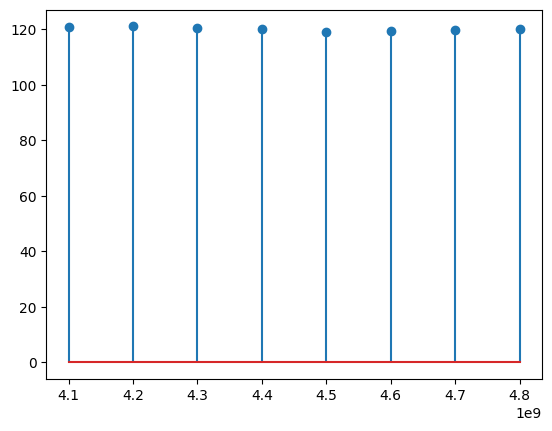

In [ ]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 0)

# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.1e9 + f * 100e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")


# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 154e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 154e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16

t = 2.048e-6
time_line = np.linspace(0, t, round(t * ADrate), endpoint=False)
combined_wave = []
for f in range(8):
    freq = 4.1e9 + f * 100e6
    wave = np.exp(2 * np.pi * freq * time_line * 1j).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.concatenate(combined_wave, axis=0)
for i in range(4):
    device.set("DemodulationParam", combined_wave, f"{slot}-I{i+1}")

program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b11111111, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b010
    witi {wait_cycle1}
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b010 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 1024
period = 900e-6
cap_num = 2
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
data = device.get("IQ", f"{slot}-I1", shots * cap_num)
plt.stem(
    [4.1e9 + f * 100e6 for f in range(8)],
    # np.abs(data[:, ::2].mean(axis=1))
    20 * np.log10(np.abs(data[:, 0::2].mean(axis=1))),
)  # 8组频点解第一个capture的结果按shot取平均
plt.show()

- FreqList 方式下发系数

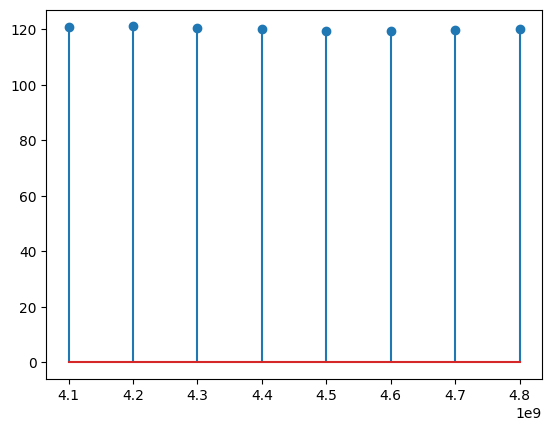

In [ ]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 0)

# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.1e9 + f * 100e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")


# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 154e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 154e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16

t = 2.048e-6
fl = []
for f in range(8):
    freq = 4.1e9 + f * 100e6
    fl.append(freq)
for i in range(4):
    device.set("TimeWidth", t, f"{slot}-I{i+1}")
    device.set("FreqList", fl, f"{slot}-I{i+1}")

program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b11111111, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b010
    # 播放和采集都使用capi指令控制，此例中的指令含义为，播放2us 1、3、5、7波形的叠加，采集2us，采集原始时域数据，采样延迟为154ns
    witi {wait_cycle1}
    # 最少wait 16倍的采样时间
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b010 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 32
period = 900e-6
cap_num = 2
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(1.5)
data = device.get("IQ", f"{slot}-I1", shots * cap_num)
plt.stem(
    [4.1e9 + f * 100e6 for f in range(8)],
    # np.abs(data[:, ::2].mean(axis=1))
    20 * np.log10(np.abs(data[:, 0::2].mean(axis=1))),
)  # 8组频点解第一个capture的结果按shot取平均
plt.show()



### 指令集画圆

In [134]:
slot = "S9"
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 0)

# 配置解模系数
t = 2.048e-6

fl = []
for f in range(8):
    freq = 4.1e9
    fl.append(freq)
for i in range(4):
    device.set("TimeWidth", t, f"{slot}-I{i+1}")
    device.set("FreqList", fl, f"{slot}-I{i+1}")

# for i in range(4):
#     combined_wave = []
#     for j in range(8):
#         freq = 4.1e9
#         time_line = np.linspace(0, t, round(t * ADrate), endpoint=False)
#         wave = np.exp(2 * np.pi * freq * time_line * 1j).reshape((1, -1))
#         combined_wave.append(wave)
#     combined_wave = np.concatenate(combined_wave, axis=0)
#     device.set("DemodulationParam", combined_wave, f"S9-I{i+1}")

# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 154e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 154e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16

shots = 512 * 2 * 4
period = 1900e-6

code = """
    capi {}, {}, {}, {}, 0b010
    witi {}
    nop
    nop
    nop
"""
angles = np.array([])
phis = np.linspace(0, 360, 19)
wave_amp = 0.1

plt.figure(figsize=(10, 5), dpi=500)
for step in [0,8,16]:
    phis_seg = phis[step : step + 8]
    cap_num = phis_seg.size
    combined_wave = []
    for phi in phis_seg:
        freq = 4.1e9
        wave_width = 2e-6
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line + phi * (np.pi / 180)).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    # 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
    # amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
    device.set("Waveform", combined_wave, f"{slot}-O1")
    enable_wave = 0b00000001
    program = f"""
        nop
        nop
        nop
        nop
        wtg             ##  等待触发
        nop
        nop
        nop""" + "".join([code.format(enable_wave<<offset, sampling_cycle1, in_delay_cycle1, play_cycle1, wait_cycle1) for offset in range(cap_num)]) + \
        """jali $0
        nop
        nop
        nop"""
    # 指令也需要下发给OUT通道
    for i in range(4):
        device.set("Assemble", program, f"S9-O{i+1}")
    # device.set("Assemble", program, f"S9-O1")

    qsync.set("Shot", shots)
    device.set("Shot", shots)
    device.set("StartCapture")
    qsync.set("GenerateTrig", period)
    print(shots, cap_num, shots* cap_num)
    # time.sleep(1)

    data = device.get("IQ", f"{slot}-I1", round(shots * cap_num))
    a = device.get('CustomALite', f"{slot}-I{ch}", 0x01F100A0)
    b = device.get("CustomALite", f"{slot}-I{ch}", 0x01F100A4)
    c = device.get("CustomALite", f"{slot}-I{ch}", 0x01F100A8)
    d = device.get("CustomALite", f"{slot}-I{ch}", 0x01F100AC)
    print(f"{a} {b} {c} {d} {data.shape}")
    res = np.array([])
    for i in range(cap_num):
        phi_spectrum = data[0, i::cap_num]
        I = phi_spectrum.real
        Q = phi_spectrum.imag
        phi_spectrum_norm = [math.sqrt(i**2 + q**2) for i, q in zip(I, Q)]
        phi_spectrum = np.array([a / b for a, b in zip(phi_spectrum, phi_spectrum_norm)])
        phi_spectrum = phi_spectrum.T
        I = phi_spectrum.real
        Q = phi_spectrum.imag

        plt.scatter(I, Q, label=f"Phase={phis_seg[i]}")
        plt.axis("equal")
        plt.ylabel("Q(V)")
        plt.xlabel("I(V)")
        plt.xlim(-5, 5)
        plt.ylim(-1.8, 1.8)
        plt.grid(True)
        plt.legend()

plt.legend(prop={"size": 9}, loc="upper left")
plt.show()

4096 8 32768
[] [] [] [] (8, 32768)
4096 8 32768
[] [] [] [] (8, 32768)
4096 3 12288


### 8.3.4 读取延迟配置

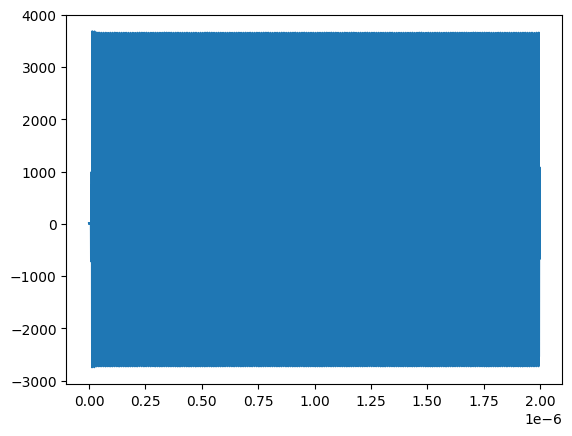

In [122]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 1)
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.3e9 + f * 50e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")

# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 152e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 4e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16


program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b1010101, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b001
    # 播放和采集都使用capi指令控制，此例中的指令含义为，播放2us 1、3、5、7波形的叠加，采集2us，采集原始时域数据，采样延迟为154ns
    witi {wait_cycle1}
    # 最少wait 16倍的采样时间
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b001 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 1024
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(5)
data = device.get("TraceIQ", f"{slot}-I1")

# data为一次上行所有shot的采样数据，需要手动reshape
data = data.reshape((-1, round(sampling_width1 * ADrate + sampling_width2 * ADrate)))
plt.figure()

# 画出第一次采集的图像
plt.plot(np.linspace(0, sampling_width1, round(sampling_width1 * ADrate), endpoint=False),
         data.mean(axis=0)[:round(sampling_width1 * ADrate)])
# plt.plot(data)
plt.show()

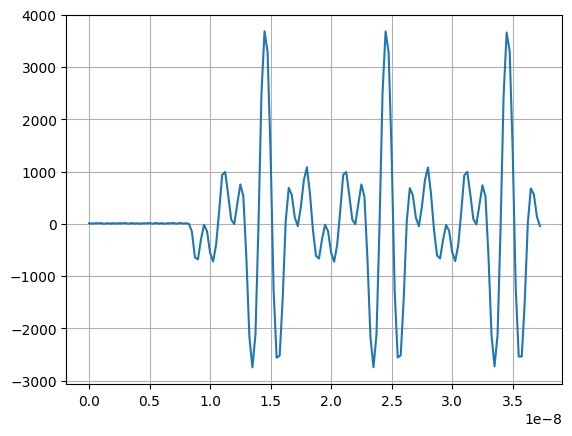

In [127]:
# 画出前150 个点，信号播放大约比采集慢8ns
plt.plot(np.linspace(0, sampling_width1, round(sampling_width1 * ADrate), endpoint=False)[:150],
         data.mean(axis=0)[:round(sampling_width1 * ADrate)][:150])
plt.grid()
plt.show()

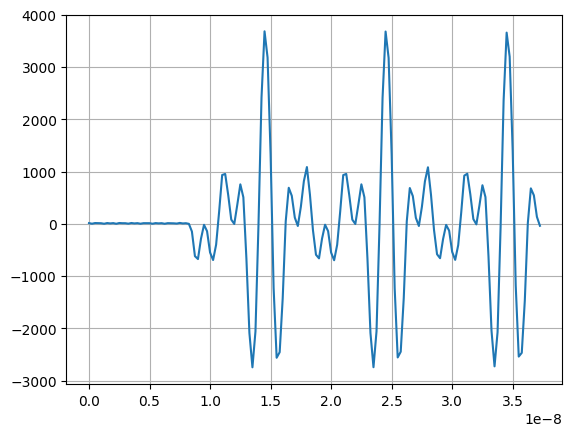

In [131]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 1)
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.3e9 + f * 50e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")

# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 153e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 4e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16


program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b1010101, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b001
    # 播放和采集都使用capi指令控制，此例中的指令含义为，播放2us 1、3、5、7波形的叠加，采集2us，采集原始时域数据，采样延迟为154ns
    witi {wait_cycle1}
    # 最少wait 16倍的采样时间
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b001 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 1024
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(5)
data = device.get("TraceIQ", f"{slot}-I1")

# data为一次上行所有shot的采样数据，需要手动reshape
data = data.reshape((-1, round(sampling_width1 * ADrate + sampling_width2 * ADrate)))
plt.figure()

plt.plot(np.linspace(0, sampling_width1, round(sampling_width1 * ADrate), endpoint=False)[:150],
         data.mean(axis=0)[:round(sampling_width1 * ADrate)][:150])
plt.grid()
plt.show()

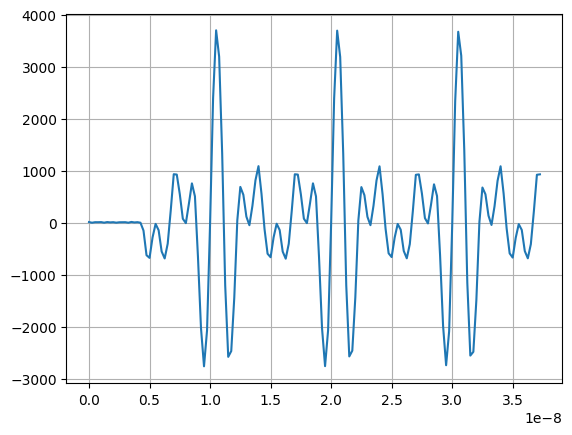

In [133]:
slot = "S9"

# 设置CaptureMode 为1，获取全部shot的数据c
device.set("CaptureMode", 1)
cycle = round((ADrate * 1e-9) * (DArate * 1e-9) * 0.125)
# 下发波形，每个OUT通道最多存储8段波形，8G下最大存储波形为2us。
# amp 设置为0.1，防止波形叠加后波形最大绝对值大于1
for i in range(4):
    combined_wave = []
    for f in range(8):
        freq = 4.3e9 + f * 50e6
        wave_width = 2e-6
        wave_amp = 0.1
        shots = 1024
        time_line = np.linspace(
            0, wave_width, round(wave_width * DArate), endpoint=False
        )
        wave = wave_amp * np.cos(2 * np.pi * freq * time_line).reshape((1, -1))
        combined_wave.append(wave)
    combined_wave = np.vstack(combined_wave)
    device.set("Waveform", combined_wave, f"{slot}-O{i+1}")

# 设置第一段波形的播放时长
play_width1 = 2e-6
play_cycle1 = round(play_width1 * 1e9 / cycle)
# 设置第二段波形的播放时长
play_width2 = 1e-6
play_cycle2 = round(play_width2 * 1e9 / cycle)

# 播放和采集由一句指令下发，需要调整采集相对于播放的延迟，对齐播放和采集
in_delay1 = 156e-9
in_delay_cycle1 = round(in_delay1 * 1e9 / cycle)
in_delay2 = 4e-9
in_delay_cycle2 = round(in_delay2 * 1e9 / cycle)

# 设置第一次的采集时长
sampling_width1 = 2e-6
sampling_cycle1 = round(sampling_width1 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle1 = sampling_cycle1 * 16

# 设置第二次的采集时长
sampling_width2 = 1e-6
sampling_cycle2 = round(sampling_width2 * 1e9 / cycle)
# 延迟时长最小为采集时长的16倍
wait_cycle2 = sampling_cycle2 * 16


program = f"""
    nop
    nop
    nop
    nop
    wtg             ##  等待触发
    nop
    nop
    nop
    capi 0b1010101, {sampling_cycle1}, {in_delay_cycle1}, {play_cycle1}, 0b001
    # 播放和采集都使用capi指令控制，此例中的指令含义为，播放2us 1、3、5、7波形的叠加，采集2us，采集原始时域数据，采样延迟为154ns
    witi {wait_cycle1}
    # 最少wait 16倍的采样时间
    nop
    nop
    nop
    capi 0b0101010, {sampling_cycle2}, {in_delay_cycle2}, {play_cycle2}, 0b001 
    witi {wait_cycle2}
    nop
    nop
    nop
    jali $0
    nop
    nop
    nop
"""
# 指令也需要下发给OUT通道
for i in range(4):
    device.set("Assemble", program, f"{slot}-O{i+1}")

shots = 1024
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(6)
data = device.get("TraceIQ", f"{slot}-I1")

# data为一次上行所有shot的采样数据，需要手动reshape
data = data.reshape((-1, round(sampling_width1 * ADrate + sampling_width2 * ADrate)))
plt.figure()

plt.plot(np.linspace(0, sampling_width1, round(sampling_width1 * ADrate), endpoint=False)[:150],
         data.mean(axis=0)[:round(sampling_width1 * ADrate)][:150])
plt.grid()
plt.show()

# 指令集简易封装

In [ ]:
from typing import Any


cycle = (ADrate * 1e-9) * (DArate * 1e-9 ) * 0.125 
def nop(args=[]):
    return {
        "ass": "nop",
        "swallow": [],
        "cycle": 1,
        "next": [],
        "value": [*args],
        "delay_cycle": 0
    }


def wait_trig(args=[]):
    return {
        "ass": "wtg",
        "swallow": [],
        "cycle": 1,
        "next": [nop()["ass"], ] * 3,
        "value": [*args],
        "delay_cycle": 0
    }




def capture_and_play(args):
    # assert x / cycle 非负整数
    funcs = [
        lambda x:x,
        lambda x:x/cycle,
        lambda x:x/cycle,
        lambda x:x/cycle,
        lambda x:x,
    ]
    args = [f(i) for f, i in zip(funcs, args)]
    print( args[1] % 1 , args[2] % 1 , args[3] % 1 )
    assert args[1] % 1 == 0 and args[2] % 1 == 0 and args[3] % 1 == 0 
    cmd_dict = {
        "ass": "capi {} {} {} {} {}",
        "swallow": [],
        "cycle": 1,
        "next": [
            nop()["ass"],
        ]
        * 0,
        "value": [*args],
        # "assert": []
        "delay_cycle": 0
    }
    cmd_dict["delay_cycle"] = args[1] + args[2] # delay_cycle 的时间段不做事
    return cmd_dict


def wait(args):
    # assert  (x / cycle - 5) # 非负整数
    funcs = [
        lambda x: (x / cycle - 5),  # cycle + len("next")
    ]
    args = [f(i) for f, i in zip(funcs, args)]
    return {
        "ass": "witi {}",
        "swallow": ["witi", "plyi", "capi"],  # 吞掉前方的指令耗时？并且自己的耗时要吞掉
        "cycle": 2,
        "next": [
            nop()["ass"],
        ]
        * 3,
        "value": [*args],
        "delay_cycle": 0
    }

# fmsi {frameID} {频率值} {相位值}
# Fmsi 0b101 30 10
# 将频率和相位值配置到指定 frame 上


def dreset(args=[]):
    return {
        "ass": "drst",
        "swallow": [],  # 吞掉前方的指令耗时？并且自己的耗时要吞掉
        "cycle": 1,
        "next": [
            nop()["ass"],
        ]
        * 5,
        "value": [*args],
        "delay_cycle": 0
    }


def jump(args):
    return {
        "ass": "jali ${}",
        "swallow": [],
        "cycle": 2,
        "next": [
            nop()["ass"],
        ]
        * 3,
        "value": [*args],
        "delay_cycle": 0
    }

class Assembly:

    def __init__(self) -> None:
        self.capi_num = 0
        self.cycle = 4 # 单位ns
        self.cg = self.code_generate()
        # self.cg.send(None)
        self.surface_cmd = []
        self.time_line = [] # 一个成员一个cycle

    def __call__(self, cmd):
        self.surface_cmd.append(cmd)
        # return self.cg.send(ass_dict)

    def play(self, args):
        return {
            "ass": "plyi 0 {} {} {} 0 0 0",
            "swallow": ["drst"],
            "cycle": 2,
            "next": [
                nop()["ass"],
            ]
            * 0,
            "value": [*args],
            "delay_cycle": 0
        }


    def code_generate(self):
        """生成器，进来一个指令会观察上一条指令，由于生成器的特性，
        暂定进来一条返回上一条指令
        """
        last_code = nop()
        # last_code["ass"] = "nop\nnop\nnop\nnop"
        # generated_code = []
        while True:
            # generated_code.append(last_code["ass"])
            code = yield last_code["ass"]
            # print(last_code, 1)
            # print(last_code["ass"].split(" ")[0], code["swallow"])
            if last_code["ass"].split("\n")[-1].split(" ")[0] in code["swallow"]:
                # 当前指令会吞上一条指令，一般发生在当前指令是wait
                code["ass"] = code["ass"].format(
                    round(
                        code["value"][0]
                        - last_code["cycle"]
                        + last_code["delay_cycle"]
                        # - len(code["next"])
                    )
                )
            else:
                code["ass"] = code["ass"].format(*[round(i) for i in code["value"]])
            if "capi" in code["ass"]:
                self.capi_num += 1
            if code["next"]:
                code["ass"] += "\n" + "\n".join(code["next"])
            # if code["ass"] ## jump
            last_code = code
            # print(last_code, "!!!!")

## S21

In [ ]:
freq_range = np.linspace(4.1e9, 8.1e9, 51)
slot = "S9"
ch = 1
shots = 1024
period = 900e-6
wave_amp = 1
device.set("CaptureMode", 0)

t = 2e-6
time_line_ad = np.linspace(0, t, round(t * ADrate), endpoint=False)
time_line_da = np.linspace(0, t, round(t * DArate), endpoint=False)

cg = Assembly()
sampling_width1 = 2000  # ns
play_width1 = 2000  # ns
process = [
    cg(wait_trig()),
    cg(capture_and_play([0b01, sampling_width1, 154, play_width1, 0b010])),
    cg(wait([sampling_width1 * 16])),
    cg(wait([200])),
    cg(jump([0])),
]
for i in range(4):
    device.set("Assemble", "\n".join(process), f"{slot}-O{i+1}")

s21_res = []
for freq in tqdm(freq_range):
    wave = wave_amp * np.cos(2 * np.pi * freq * time_line_da).reshape((1, -1))
    wave_dp = np.exp(2 * np.pi * freq * time_line_ad * 1j).reshape((1, -1))

    for i in range(4):
        #  TODO 只下发一个。报错
        device.set("Waveform", wave, f"{slot}-O{i+1}")
        device.set("DemodulationParam", wave_dp, f"{slot}-I{i+1}")

    # for i in range(4):
    #     device.set("Assemble", "\n".join(process), f"{slot}-O{i+1}")

    qsync.set("Shot", shots)
    device.set("Shot", shots)
    device.set("StartCapture")
    qsync.set("GenerateTrig", period)
    # time.sleep(1)
    data = device.get("IQ", f"{slot}-I{ch}", shots * 1)
    s21_res.append(data[0])
    # print(s21_res)
s21_res = np.array(s21_res).mean(axis=1)
s21_power = 20 * np.log(np.abs(s21_res))
plt.plot(freq_range, s21_power)
plt.show()

  0%|          | 0/51 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
cg = code_generate()
process = [
    cg.send(None),
    cg.send(wait_trig()),
    cg.send(capture_and_play([0b01, sampling_width1, 154, play_width1, 0b010])),
    cg.send(wait([sampling_width1 * 16])),
    cg.send(wait([sampling_width1 * 16])),
    cg.send(jump([0])),
]

In [ ]:
print("\n".join(process))

nop
nop
nop
nop
wtg
nop
nop
nop
capi 1 500 38 500 2
witi 7994
nop
nop
nop
witi 7995
nop
nop
nop
jali $0
nop
nop
nop


# 10. 编译器NSWave

## 10.1 XY使用教程

In [1]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.18"
qsync_ip = "192.168.110.18"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 1,
    "RefClock": "out",
    "DArate_S9-O1": DArate_xy,
    # "DArate_S9-O1": DArate_rd,
    # "DArate_S13-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.18开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.18 opened successfully
*********设备192.168.110.18开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-1-g56dc731
ad_num: 4
da_num: 12
cpu_temp: 39.0
memory_use: 8.7
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.18开启成功
System synchronization succeeded


### 10.1.1 控制波形播放

In [189]:
slot = "S9"
ch = 1

@nw.kernel
def program_1(envelope: np.ndarray):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    freq: nw.Var = 400e6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    # nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()
_k1 = program_1()

device.set('Program', _k1, f'{slot}-O{ch}')

shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

### 10.1.2 点频连续波模式

### 10.1.3 播放延迟设置

In [190]:
slot = "S9"
ch = 1

@nw.kernel
def program_1(outdelay: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    freq: nw.Var = 400e6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(outdelay)
    nw.play_wave(envelope_0, 1, 0, 0)
    # nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()
_k1 = program_1(40e-9)

device.set('Program', _k1, f'{slot}-O{ch}')

shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

In [196]:
slot = "S9"
ch = 1

@nw.kernel
def program_1(outdelay: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    freq: nw.Var = 400e6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(outdelay)
    nw.play_wave(envelope_0, 1, 0, 0)
    # nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()
_k1 = program_1(42e-9)

device.set('Program', _k1, f'{slot}-O{ch}')

shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

In [198]:
slot = "S9"
ch = 1

@nw.kernel
def program_1(outdelay: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    freq: nw.Var = 400e6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.append(np.zeros(round(srate*2e-9)), np.cos(2 * np.pi * time_line * freq))
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(outdelay)
    nw.play_wave(envelope_0, 1, 0, 0)
    # nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()
_k1 = program_1(40e-9)

device.set('Program', _k1, f'{slot}-O{ch}')

shots = 0xFFFFFFFF
qsync.set('Shot', shots)
qsync.set('GenerateTrig', 400e-6)

## 10.1 RD使用教程

In [12]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.16"
qsync_ip = "192.168.110.16"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 6e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 1,
    "RefClock": "out",
    "DArate_S12-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    "DArate_S13-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.16开启成功*********
core_temp: 0℃
10M_locked: nan
qsync 192.168.110.16 opened successfully
*********设备192.168.110.16开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 0
da_num: 0
cpu_temp: 38.0
memory_use: 11.7
available chnl: 
OUT Chnl: [] 

IN  Chnl: []
192.168.110.16开启成功
System synchronization succeeded


### 10.1.1 读取下发激励

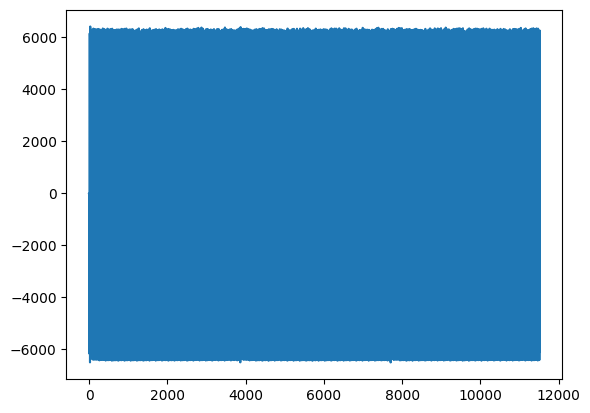

In [10]:

slot = "S9"
period = 400e-6

ch = 2

wave_width = 2e-6
wave_amp = 1
time_line = np.linspace(
    0, wave_width, round(wave_width * DArate_rd), endpoint=False
)

combined_wave = []
mask = [1, 0, 0, 0, 0, 0, 0, 0]
for f in range(1):
    freq = 4.3e9 * mask[f]
    wave = wave_amp * np.sin(2 * np.pi * freq * time_line).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.vstack(combined_wave)
device.set("Waveform", combined_wave, f"{slot}-O{ch}")
# 播放时8组波形全部播放，现在设置第一组有波形，其余全为0

@nw.kernel
def probe_program():
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.capture(0.96e-6, 154e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    nw.capture(0.96e-6, 154e-9, 2e-6)    
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    nw.capture(0.96e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()

for i in range(4):
    device.set('Program', probe_program(), f"{slot}-O{i+1}")   
    # program 需要下发给out通道      

cap_point = 3 * 2e-6 * ADrate # 一个program的总采样点数

shots = 512
period = 900e-6
device.set("CaptureMode", 1) # 原始数据CaptureMode需要设置为1
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(2) # 需要等待2s上传数据
assert shots * cap_point <= 67108864  # 总采样点数不能超过 8388608, 通过调整shot和采样点设置
data = device.get("TraceIQ", f"{slot}-I{ch}", )
data = data.reshape((shots, -1))
plt.figure()
plt.plot(data.mean(axis=0))
plt.show()

In [138]:
%matplotlib qt5 
# plt_fft(combined_wave)
plt.plot(combined_wave[0])
plt.show()

In [ ]:
data.shape

(512, 16000)

### 10.1.2 解模系数下发

#### 10.1.2.1 FreqList 

In [8]:
freqs = [4.3e9, 0, 0, 0, 0, 0, 4.3e9, 0]
device.set('FreqList',freqs, f"{slot}-I{ch}")

#### 10.1.2.2 DemodulationParam

In [138]:
wave_ad = []
mask = [1, 0, 0, 0, 0, 0, 1, 0]
ad_width = 2.048e-6
freq = 4.3e9
time_line_ad = np.linspace(
    0, ad_width, round(ad_width * ADrate), endpoint=False
)
for i in range(8):
    wave_ad.append(np.exp(2 * np.pi * (freq*mask[i]) * time_line_ad * 1j))
wave_ad = np.array(wave_ad)
device.set("DemodulationParam", wave_ad, f"{slot}-I{ch}")
# 下发自己生成的解模系数

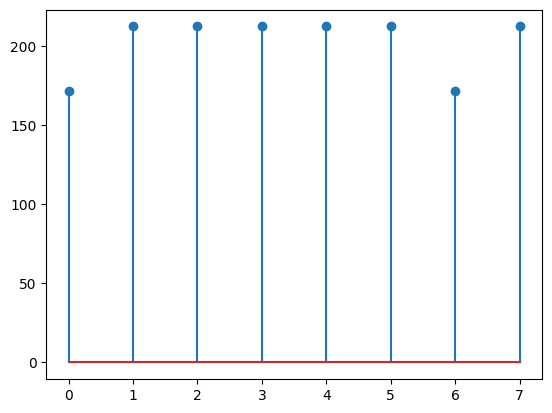

In [139]:

slot = "S9"
ch = 1
cap_num = 2

wave_width = 2e-6
wave_amp = 1
time_line = np.linspace(
    0, wave_width, round(wave_width * DArate_rd), endpoint=False
)

# freqs = [4.3e9, 0, 0, 0, 0, 0, 4.3e9, 0]
# device.set('FreqList',freqs, f"{slot}-I{ch}")

combined_wave = []
mask = [1, 0, 0, 0, 0, 0, 0, 0]
for f in range(8):
    freq = 4.3e9 * mask[f]
    wave = wave_amp * np.sin(2 * np.pi * freq * time_line).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.vstack(combined_wave)
device.set("Waveform", combined_wave, f"{slot}-O{ch}")
# 播放时8组波形全部播放，现在设置第一组有波形，其余全为0

@nw.kernel
def probe_program():
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.capture(2e-6, 154e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(4e-9)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    nw.capture(2e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()

for i in range(4):
    device.set('Program', probe_program(), f"{slot}-O{i+1}")   
    # program 需要下发给out通道      

shots = 512
period = 16e-6
device.set("CaptureMode", 0) # 解模数据模式需要设置为0
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
data = device.get("IQ", f"{slot}-I{ch}", cap_num * shots)  # 指定需要获取的数据量
cap1 = data[:, 0::cap_num]
cap2 = data[:, 1::cap_num]
plt.stem(20 * np.log(np.abs(cap2.mean(axis=1))))
plt.show()


### 10.1.4 读取延迟配置

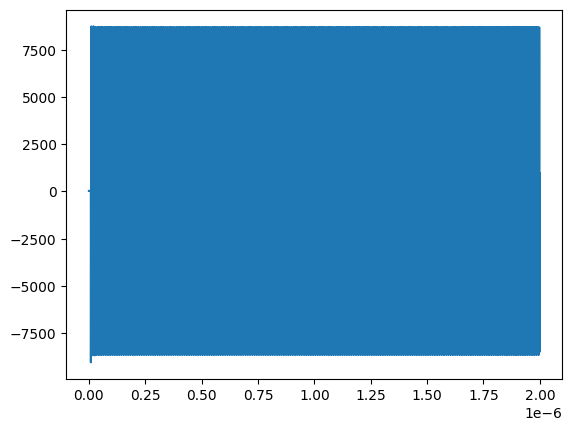

In [28]:

slot = "S9"
period = 400e-6

ch = 1

device.set("CaptureMode", 1) # 原始数据CaptureMode需要设置为1
wave_width = 2e-6
wave_amp = 1
time_line = np.linspace(
    0, wave_width, round(wave_width * DArate_rd), endpoint=False
)

combined_wave = []
mask = [1, 0, 0, 0, 0, 0, 0, 0]
for f in range(8):
    freq = 4.3e9 * mask[f]
    wave = wave_amp * np.sin(2 * np.pi * freq * time_line).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.vstack(combined_wave)
device.set("Waveform", combined_wave, f"{slot}-O{ch}")
# 播放时8组波形全部播放，现在设置第一组有波形，其余全为0

@nw.kernel
def probe_program():
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.capture(2e-6, 152e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    # nw.capture(2e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()

for i in range(4):
    device.set('Program', probe_program(), f"{slot}-O{i+1}")   
    # program 需要下发给out通道      

cap_point = 2 * 2e-6 * ADrate # 一个program的总采样点数

shots = 512
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(2) # 需要等待2s上传数据
assert shots * cap_point <= 8388608  # 总采样点数不能超过 8388608, 通过调整shot和采样点设置
data = device.get("TraceIQ", f"{slot}-I{ch}", 1 * shots)
data = data.reshape((shots, -1))
plt.figure()
plt.plot(np.linspace(0, 2e-6, round(2e-6*ADrate), endpoint=False), data.mean(axis=0))
plt.show()

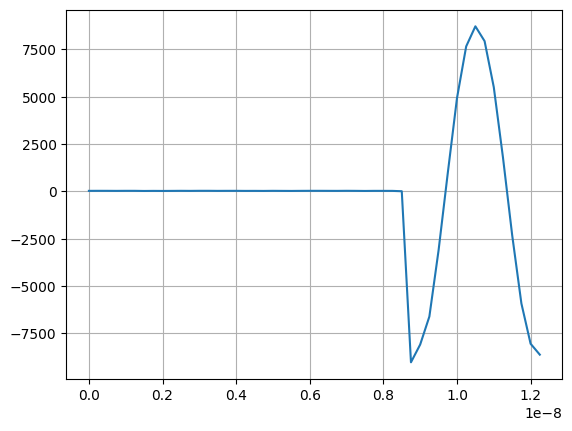

In [29]:
plt.plot(np.linspace(0, 2e-6, round(2e-6*ADrate), endpoint=False)[:50], data.mean(axis=0)[:50])
plt.grid()
plt.show()

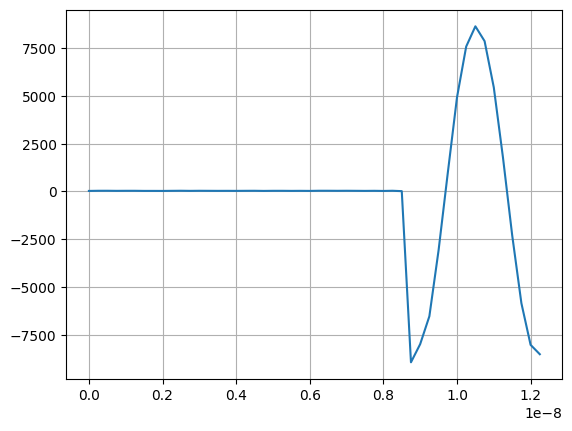

In [22]:

slot = "S9"
period = 400e-6

ch = 1

device.set("CaptureMode", 1) # 原始数据CaptureMode需要设置为1
wave_width = 2e-6
wave_amp = 1
time_line = np.linspace(
    0, wave_width, round(wave_width * DArate_rd), endpoint=False
)

combined_wave = []
mask = [1, 0, 0, 0, 0, 0, 0, 0]
for f in range(8):
    freq = 4.3e9 * mask[f]
    wave = wave_amp * np.sin(2 * np.pi * freq * time_line).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.vstack(combined_wave)
device.set("Waveform", combined_wave, f"{slot}-O{ch}")
# 播放时8组波形全部播放，现在设置第一组有波形，其余全为0

@nw.kernel
def probe_program():
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.capture(2e-6, 153e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    # nw.capture(2e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()

for i in range(4):
    device.set('Program', probe_program(), f"{slot}-O{i+1}")   
    # program 需要下发给out通道      

cap_point = 2 * 2e-6 * ADrate # 一个program的总采样点数

shots = 512
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(2) # 需要等待2s上传数据
assert shots * cap_point <= 8388608  # 总采样点数不能超过 8388608, 通过调整shot和采样点设置
data = device.get("TraceIQ", f"{slot}-I{ch}", 1 * shots)
data = data.reshape((shots, -1))
plt.figure()
plt.plot(np.linspace(0, 2e-6, round(2e-6*ADrate), endpoint=False)[:50], data.mean(axis=0)[:50])
plt.grid()
plt.show()

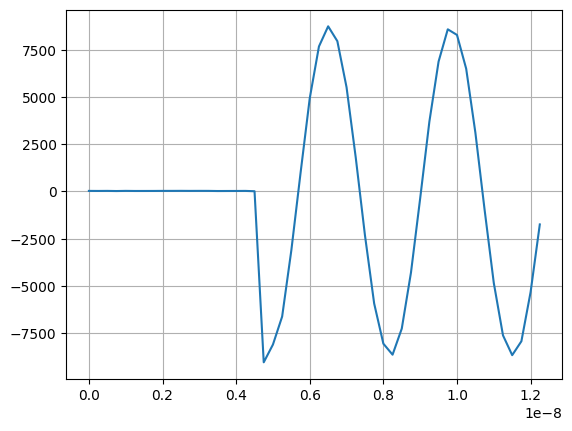

In [30]:

slot = "S9"
period = 400e-6

ch = 1

device.set("CaptureMode", 1) # 原始数据CaptureMode需要设置为1
wave_width = 2e-6
wave_amp = 1
time_line = np.linspace(
    0, wave_width, round(wave_width * DArate_rd), endpoint=False
)

combined_wave = []
mask = [1, 0, 0, 0, 0, 0, 0, 0]
for f in range(8):
    freq = 4.3e9 * mask[f]
    wave = wave_amp * np.sin(2 * np.pi * freq * time_line).reshape((1, -1))
    combined_wave.append(wave)
combined_wave = np.vstack(combined_wave)
device.set("Waveform", combined_wave, f"{slot}-O{ch}")
# 播放时8组波形全部播放，现在设置第一组有波形，其余全为0

@nw.kernel
def probe_program():
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.capture(2e-6, 156e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    # nw.capture(2e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()

for i in range(4):
    device.set('Program', probe_program(), f"{slot}-O{i+1}")   
    # program 需要下发给out通道      

cap_point = 2 * 2e-6 * ADrate # 一个program的总采样点数

shots = 512
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set("StartCapture")
qsync.set("GenerateTrig", period)
time.sleep(2) # 需要等待2s上传数据
assert shots * cap_point <= 8388608  # 总采样点数不能超过 8388608, 通过调整shot和采样点设置
data = device.get("TraceIQ", f"{slot}-I{ch}", 1 * shots)
data = data.reshape((shots, -1))
plt.figure()
plt.plot(np.linspace(0, 2e-6, round(2e-6*ADrate), endpoint=False)[:50], data.mean(axis=0)[:50])
plt.grid()
plt.show()

#### 10.1.4.3 播放和采集信号相位匹配

In [120]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.12"
qsync_ip = "192.168.110.12"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 6e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 1,
    "RefClock": "out",
    "DArate_S12-O1": DArate_xy,
    "DArate_S9-O1": DArate_rd,
    "DArate_S13-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.12开启成功*********
core_temp: 999℃
10M_locked: 0
qsync 192.168.110.12 opened successfully
*********设备192.168.110.12开启成功*********
device_type: pqtm
backend_version: v2.5.1-b1-16-gd3703c4
ad_num: 4
da_num: 20
cpu_temp: 42.0
memory_use: 14.3
available chnl: 
OUT Chnl: ['S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.12开启成功
System synchronization succeeded


[[1.         0.97236992 0.89100652 ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         1.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]
[[0.         0.         0.         ...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[0.         0.         0.         ... 0.76040597 0.89100652 0.97236992]]


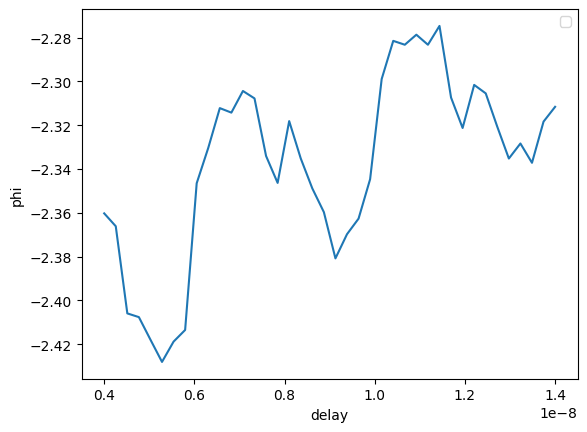

In [128]:

slot = "S9"
period = 400e-6

ch = 1

freq = 0.3e9
device.set("CaptureMode", 0) # 原始数据CaptureMode需要设置为1
wave_width = 2e-6
in_width = 2e-6
wave_amp = 1
time_line = np.linspace(0, wave_width, round(wave_width * DArate_rd), endpoint=False)
wave = wave_amp * np.cos(2 * np.pi * freq * time_line)

rd_delay = np.linspace(4e-9, 14e-9, 40)

@nw.kernel
def probe_program(oidelay:nw.Var):
    nw.wait_for_trigger()
    nw.wait(200e-9)
    # trig 来后等待200ns
    nw.wait(oidelay)
    nw.capture(2e-6, 200e-9, 2e-6)
    # 第一次采集. 采样时间是2us，播放时间是2us，采样相对于播放延迟154ns
    nw.wait(2e-6 * 16)
    # 时域原始数据两次capture之间要wait上一次的采样时间*16
    # nw.capture(2e-6, 154e-9, 2e-6)
    # nw.wait(2e-6 * 18)
    return nw.Kernel()
   
    # program 需要下发给out通道      


cap_point = in_width * ADrate # 一个program的总采样点数

shots = 512
period = 900e-6
qsync.set("Shot", shots)
device.set("Shot", shots)
device.set('FreqList', [freq], f"{slot}-I{ch}")
assert shots * cap_point <= 8388608  # 总采样点数不能超过 8388608, 通过调整shot和采样点设置
plt.figure(1)
phi_set = []
for idx, delay in enumerate(rd_delay):
    intdelay = rd_delay[idx] // 4e-9 * 4e-9 
    numofzero = (rd_delay[idx] - intdelay) * DArate_rd
    # numofzero = 0

    for i in range(4):
        device.set('Program', probe_program(delay), f"{slot}-O{i+1}")  
    device.set('Waveform', np.array([np.append(np.zeros(round(numofzero)), wave)]), f"{slot}-O{ch}")
    print(np.array([np.append(np.zeros(round(numofzero)), wave)])[:10])
    # print(numofzero)
    device.set('StartCapture')
    qsync.set('GenerateTrig')
    data = device.get('IQ', f"{slot}-I{ch}", shots)
    data = data[0].mean(axis=0)
    phi = np.angle(data)
    phi_set.append(phi)
plt.plot(rd_delay, phi_set)
# plt.plot(rd_delay, [phi_set[0]]*len(phi_set), label = f'播放波形相位')
plt.ylabel('phi')
plt.xlabel('delay')
plt.legend()
plt.show()  



# 11. nswave表征实验

In [ ]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "172.16.153.203"
qsync_ip = "172.16.153.203"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

In [ ]:
@nw.kernel

def program(wave_list: nw.Var):
    srate: nw.Var = 8e9
    i: nw.Var = 0
    time_width: nw.Var = 2e-6
    freq: nw.Var = 100e6
    time_line_1: np.ndarray = np.linspace(0, time_width, int(time_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line_1 * freq)
    envelope: nw.Envelope
    frame: nw.frame = nw.init_frame(0, 0.5 * np.pi)
    nw.wait_for_trigger()
    for wave in wave_list:

        envelope: nw.Envelope = nw.ins_envelope(wave)

        nw.play_wave(envelope, 1, 0, 0)

nw.wait(2.8e-6)



return nw.Kernel()



da_srate = 8e9

time_width = 1e-6

freq_1 = 4.1e9

freq_2 = 4.11e9

freq_3 = 4.12e9

time_line = np.linspace(0, time_width, da_srate * time_width, endpoint=False)

wave_list = [np.cos(time_line * freq_1), np.cos(time_line * freq_2), np.cos(time_line *freq_3)]



k1 = program(wave_list)

## 11.1 S21

*********QSYNC192.168.110.16开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.16 opened successfully
*********设备192.168.110.16开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 41.0
memory_use: 13.9
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.16开启成功
System synchronization succeeded


  0%|          | 0/101 [00:00<?, ?it/s]

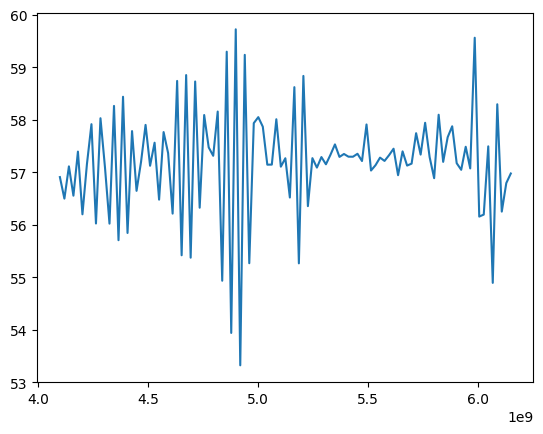

In [29]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.16"
qsync_ip = "192.168.110.16"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot = 9
ch = 1
cap_num = 1 # 配置一个trig 中采集的次数
@nw.kernel
def program_cap(param: nw.Var):
    # 可传递相关配置参数
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        # 通过for 循环可多次生成指令
        nw.wait(i[0]) # 生成wait指令
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3]) # 生成采集指令
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

da_width = 2e-6
device.set('Program', program_cap([
    [100e-9, 2e-6, 156e-9, da_width],
    ]*cap_num), f"S{slot}-O{ch}")
# cap之间的间隔必须大于4ns

freq_list = np.linspace(4.10e9, 6.15e9, 101)
shots = 1024
time_line = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)  # 解模数据设置为0
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

res = []
for freq in tqdm(freq_list):
    freqs = [freq + i * 500e6 for i in range(8)]
    device.set('FreqList',freqs, f"S{slot}-I{ch}")  # 设置频点
    wave = np.cos(time_line*2*np.pi*freq)
    device.set('Waveform', np.array([wave]), f"S{slot}-O{ch}")  # 下发波形，1行point number列
    device.set('StartCapture')
    time.sleep(0.1)
    qsync.set('GenerateTrig', period)
    data = device.get('IQ', f"S{slot}-I{ch}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num] # 此处取第一次采集的所有频点
    # data的shape为 [固定8个频点, capture次数*shot个数]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))

plt.plot(freq_list, np.array(res)[:, 0]) # 取第0个频点
plt.show()

## 11.2 S21 vs Power

In [33]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.16"
qsync_ip = "192.168.110.16"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()

slot = 9
ch = 1
cap_num = 3  # 设置采集次数为3次
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3])

device.set('Program', program_cap([
    [100e-9, 2e-6, 156e-9, 2e-6],
    ]*cap_num), f"S{slot}-O{ch}")
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns
freq_num = 40
power_num = 40
freq_list = np.linspace(4.1e9, 4.15e9, freq_num)
power_range = np.linspace(0, 1, power_num)
da_width = 2e-6
shots = 1024
time_line = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
s21_vs_power = []
res = []
for freq in tqdm(freq_list):
    s21_res = []
    for power in tqdm(power_range):
        freqs = [freq + i * 500e6 for i in range(8)]
        device.set('FreqList',freqs, f"S{slot}-I{ch}")
        wave = np.cos(time_line*2*np.pi*freq) * power
        device.set('Waveform', np.array([wave]), f"S{slot}-O{ch}")
        device.set('StartCapture')
        qsync.set('GenerateTrig', period)
        s21_res.append(device.get('IQ', f"S{slot}-I{ch}", round(shots*(cap_num)))[:, 0::cap_num])
    s21_vs_power.append(s21_res)
s21_vs_power = np.array(s21_vs_power).mean(axis=2)
s21_vs_power = 20*np.log10(np.abs(s21_vs_power))[:, :, 0]
# 归一化
s21_vs_power = (s21_vs_power.T-s21_vs_power.mean(axis=1))/(s21_vs_power.max(axis=1)-s21_vs_power.min(axis=1))
plt.imshow(s21_vs_power)
plt.xticks(list(range(freq_list.size))[::freq_num//10], freq_list[::freq_num//10]/1e9)
plt.yticks(list(range(power_range.size))[::power_num//10], np.around(power_range[::power_num//10],decimals=2 ))
plt.colorbar()
plt.show()

*********QSYNC192.168.110.16开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.16 opened successfully
*********设备192.168.110.16开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 43.0
memory_use: 13.9
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.16开启成功
System synchronization succeeded


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11.3 Spectrum

*********QSYNC192.168.110.16开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.16 opened successfully
*********设备192.168.110.16开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 43.0
memory_use: 13.9
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.16开启成功
System synchronization succeeded


  0%|          | 0/301 [00:00<?, ?it/s]

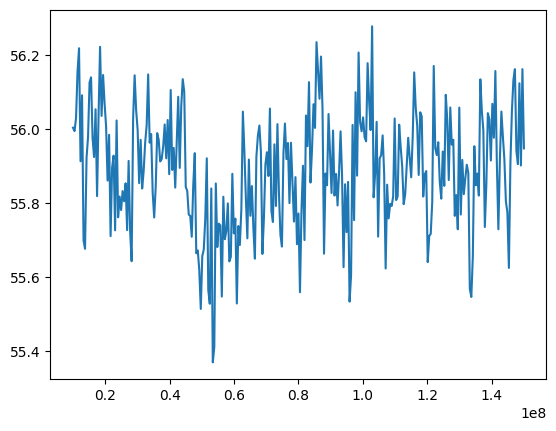

In [49]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.16"
qsync_ip = "192.168.110.16"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot_rd = 9
slot_xy = 8
ch_rd = 1
ch_xy = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

da_width = 2e-6
device.set('Program', program_cap([
    [2.06e-6, 2e-6, 156e-9, da_width],
    ]*cap_num), f"S{slot_rd}-O{ch_rd}")
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns


@nw.kernel
def program_xy(freq: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()

freq_list = np.linspace(4.01e9, 4.15e9, 301)
shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot}-O{ch}")

res = []
for freq in tqdm(freq_list):

    device.set('Program', program_xy(freq), f'S{slot_xy}-O{ch_xy}')

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    time.sleep(0.1)
    data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    res.append(20*np.log10(abs(cap1.mean(axis=1))))

plt.plot(freq_list, np.array(res)[:, 0]) # 取第0个频点
plt.show()

## 11.4 Spectrum vs Flux

In [92]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot_rd = 9
slot_xy = 8
ch_rd = 1
ch_xy = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

xy_delay = 125e-9  # 为了将xy和z的起始位置对齐

probe_width = 2e-6
device.set('Program', program_cap([
    [2.06e-6+xy_delay, 2e-6, 156e-9, probe_width],
    ]*cap_num), f"S{slot_rd}-O{ch_rd}")
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns

@nw.kernel
def program_xy(freq: nw.Var, xy_delay: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(xy_delay)
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()

freq_list = np.linspace(4.1e9, 4.15e9, 21)
shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6
bias_range = np.linspace(0, 1, 21)

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot}-O{ch}")

# 开始扫描bias
probe_bias = 0
drive_width = 2e-6
z_ch = "S11-O1"
spectrum_vs_flux = []
for bias in tqdm(bias_range):
    _z = bias*np.ones((int(drive_width*DArate_z),))
    _probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
    wave = np.hstack((_z, _probe))
    device.set('Waveform', wave, z_ch)  # 将波形下发到对应OUT通道
    # 开始按频点扫描
    spectrum_res = []
    for freq in tqdm(freq_list):

        device.set('Program', program_xy(freq, xy_delay), f'S{slot_xy}-O{ch_xy}')

        device.set('StartCapture')
        qsync.set('GenerateTrig', period)
        time.sleep(0.1)
        data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
        # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
        cap1 = data[:, 0::cap_num]
        spectrum_res.append(cap1) 
    spectrum_vs_flux.append(spectrum_res)

spectrum_vs_flux = np.array(spectrum_vs_flux).mean(axis=2)
spectrum_vs_flux = 20*np.log10(np.abs(spectrum_vs_flux))[:, :, 0] # 取结果中的第一个频点
# 归一化
spectrum_vs_flux = (spectrum_vs_flux.T-spectrum_vs_flux.mean(axis=1))/(spectrum_vs_flux.max(axis=1)-spectrum_vs_flux.min(axis=1))
plt.imshow(spectrum_vs_flux.T)
plt.colorbar()
plt.show()

*********QSYNC192.168.110.5开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.5 opened successfully
*********设备192.168.110.5开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 35.0
memory_use: 12.5
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.5开启成功
System synchronization succeeded


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [68]:
_z = bias*np.ones((int(drive_width*DArate_z),))
_probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
np.hstack((_z, _probe))

array([0.94, 0.94, 0.94, ..., 0.  , 0.  , 0.  ])

## 11.5 Power Rabi

*********QSYNC192.168.110.5开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.5 opened successfully
*********设备192.168.110.5开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 33.0
memory_use: 12.5
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.5开启成功
System synchronization succeeded


  0%|          | 0/101 [00:00<?, ?it/s]

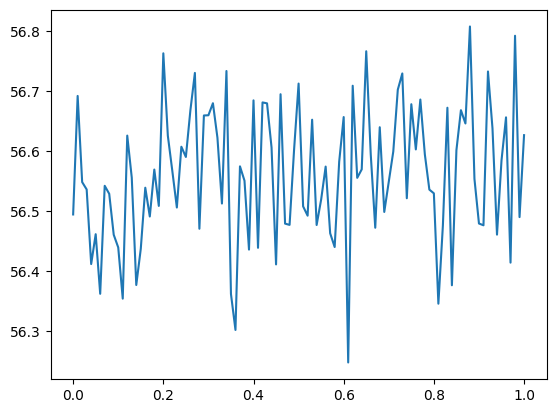

In [99]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot_rd = 9
slot_xy = 8
slot_z = 11
ch_rd = 1
ch_xy = 1
ch_z = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

xy_delay = 125e-9  # 为了将xy和z的起始位置对齐
probe_width = 2e-6
device.set('Program', program_cap([
    [2.06e-6 + xy_delay, probe_width, 156e-9, probe_width],
    ]*cap_num), f"S{slot_rd}-O{ch_rd}")
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns

@nw.kernel
def program_xy(freq: nw.Var, power: nw.Var, xy_delay: nw.Var):
    srate: nw.Var = 8e9
    time_width: nw.Var = 2e-6
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = power * np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(xy_delay)
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()

shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

power_list = np.linspace(0, 1, 101)
shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line_rd*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot_rd}-O{ch_rd}")

freq_xy = 4.2e9

z_bias = 1
probe_bias = 0
_z = z_bias*np.ones((int(drive_width * DArate_z),))
_probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
wave = np.hstack((_z, _probe))
device.set('Waveform', wave, f"S{slot_z}-O{ch_z}") 

specrum_res = []
for power in tqdm(power_list):

    device.set('Program', program_xy(freq, power, xy_delay), f'S{slot_xy}-O{ch_xy}')

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    time.sleep(0.1)
    data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    specrum_res.append(cap1[0])  # 取第一个频点

specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(power_list, specrum_power)
plt.show()



## 11.6 Time Rabi

*********QSYNC192.168.110.5开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.5 opened successfully
*********设备192.168.110.5开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 30.0
memory_use: 12.5
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.5开启成功
System synchronization succeeded


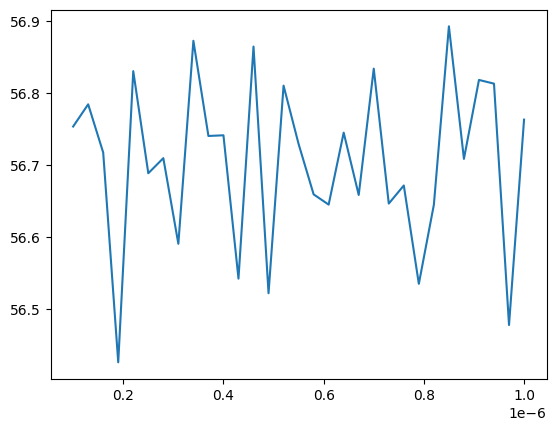

In [105]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot_rd = 9
slot_xy = 8
slot_z = 11
ch_rd = 1
ch_xy = 1
ch_z = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

xy_delay = 125e-9  # 为了将xy和z的起始位置对齐
probe_width = 2e-6

# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns

@nw.kernel
def program_xy(freq: nw.Var, time_width: nw.Var, xy_delay: nw.Var):
    srate: nw.Var = 8e9
    # time_width: nw.Var = drive_width
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(xy_delay)
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()

shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

power_list = np.linspace(0, 1, 101)
shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line_rd*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot_rd}-O{ch_rd}")

freq_xy = 0.2e9

z_bias = 1
probe_bias = 0


time_range = np.linspace(0.1e-6, 1e-6, 31)
# 开始按power扫描
specrum_res = []
for drive_width in time_range:

    _z = z_bias*np.ones((int(drive_width * DArate_z),))
    _probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
    wave = np.hstack((_z, _probe))
    device.set('Waveform', wave, f"S{slot_z}-O{ch_z}") 

    device.set('Program', program_xy(freq, drive_width, xy_delay), f'S{slot_xy}-O{ch_xy}')

    device.set('Program', program_cap([
        [60e-9 + xy_delay + drive_width, probe_width, 156e-9, probe_width],
        ]*cap_num), f"S{slot_rd}-O{ch_rd}")

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    time.sleep(0.1)
    data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    specrum_res.append(cap1[0])  # 取第一个频点

specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()



## 11.7 T1

*********QSYNC192.168.110.5开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.5 opened successfully
*********设备192.168.110.5开启成功*********
device_type: pqtm
backend_version: v2.5.8-b1-5-g50f0b1a
ad_num: 4
da_num: 20
cpu_temp: 32.0
memory_use: 12.5
available chnl: 
OUT Chnl: ['S8-O1', 'S8-O2', 'S8-O3', 'S8-O4', 'S8-O5', 'S8-O6', 'S8-O7', 'S8-O8', 'S9-O1', 'S9-O2', 'S9-O3', 'S9-O4', 'S11-O1', 'S11-O2', 'S11-O3', 'S11-O4', 'S11-O5', 'S11-O6', 'S11-O7', 'S11-O8'] 

IN  Chnl: ['S9-I1', 'S9-I2', 'S9-I3', 'S9-I4']
192.168.110.5开启成功
System synchronization succeeded


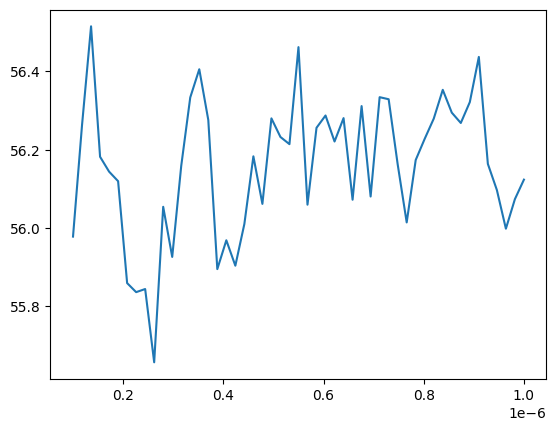

In [109]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(2)

slot_rd = 9
slot_xy = 8
slot_z = 11
ch_rd = 1
ch_xy = 1
ch_z = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

xy_delay = 125e-9  # 为了将xy和z的起始位置对齐
probe_width = 2e-6
drive_width = 2e-6
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns

@nw.kernel
def program_xy(freq: nw.Var, time_width: nw.Var, xy_delay: nw.Var):
    srate: nw.Var = 8e9
    # time_width: nw.Var = drive_width
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(xy_delay)
    nw.play_wave(envelope_0, 1, 0, 0)
    return nw.Kernel()
device.set('Program', program_xy(freq, drive_width, xy_delay), f'S{slot_xy}-O{ch_xy}')

shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

power_list = np.linspace(0, 1, 101)
shots = 1024
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)
period = 50e-6

device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line_rd*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot_rd}-O{ch_rd}")

freq_xy = 4.2e9

z_bias = 1
probe_bias = 0
_z = z_bias*np.ones((int(drive_width * DArate_z),))
_probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
wave = np.hstack((_z, _probe))
device.set('Waveform', wave, f"S{slot_z}-O{ch_z}") 


time_range = np.linspace(0.1e-6, 1e-6, 51)
# 开始按power扫描
specrum_res = []
for delta_t_rd in time_range:

    device.set('Program', program_cap([
        [60e-9 + xy_delay + drive_width + delta_t_rd, probe_width, 156e-9, probe_width],
        ]*cap_num), f"S{slot_rd}-O{ch_rd}")

    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    time.sleep(0.1)
    data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    specrum_res.append(cap1[0])  # 取第一个频点

specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()



## 11.7 T2

In [1]:
# 第1部分
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import nsqdriver.nswave as nw
from tqdm.notebook import tqdm
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

# 第2部分
SHARED_DEVICE_MEM.clear_ip()

# 第3部分
deviceIP = "192.168.110.5"
qsync_ip = "192.168.110.5"
device = MCIDriver(deviceIP, 20)
qsync = QSYNCDriver(qsync_ip)

# 第4部分
DArate_rd = 8e9
DArate_xy = 8e9
DArate_z = 2e9
ADrate = 4e9
sysparam = {
    "MixMode": 2,
    "RefClock": "out",
    "DArate_S9-O1": DArate_rd,
    "DArate_S8-O1": DArate_xy,
    "DArate_S11-O1": DArate_z,
    "ADrate": ADrate,
    "INMixMode": 1,
    # 在默认设置ADC采样率为4GSa/s时，如果腔频位于4GHz~6GHz，需要设置"INMixMode": 1；如果腔频位于6GHz~8GHz，需要设置"INMixMode": 2
    "CaptureMode": 0,
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

# 第5部分
qsync.open(system_parameter=qsync_param)
device.open(system_parameter=sysparam)
qsync.sync_system()
time.sleep(10)

slot_rd = 9
slot_xy = 8
slot_z = 11
ch_rd = 1
ch_xy = 1
ch_z = 1
cap_num = 1
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param: [[100e-9, 1e-6], [200e-9, 1e-6]]
    for i in param:
        nw.wait(i[0])
        # wait参数为 距离上一次操作完成的延迟
        nw.capture(i[1], i[2], i[3])
        #capture参数为 采样时长，采样相对于播放的延迟，播放的时长。

xy_delay = 125e-9  # 为了将xy和z的起始位置对齐
probe_width = 2e-6
drive_width = 2e-6
# 距离上一次操作完成的延迟，采样时长，采样相对于播放的延迟，播放的时长。
# cap之间的间隔必须大于4ns

@nw.kernel
def program_xy(freq: nw.Var, time_width: nw.Var, xy_delay: nw.Var, t2: nw.Var):
    srate: nw.Var = 8e9
    # time_width: nw.Var = drive_width
    time_line: np.ndarray = np.linspace(0, time_width, int(time_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_0: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.wait(xy_delay)
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(t2)
    # frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    nw.play_wave(envelope_0, 1, 0, 0) # 最后一个参数是附加相位
    return nw.Kernel()

shots = 1024
period = 1e-3
time_line_rd = np.linspace(0, da_width, round(DArate_rd*da_width), endpoint=False)

power_list = np.linspace(0, 1, 101)


device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

freq_rd = 4.2e9
freqs = [freq_rd + i * 500e6 for i in range(8)]
device.set('FreqList',freqs, f"S{slot_rd}-I{ch_rd}")
wave = np.cos(time_line_rd*2*np.pi*freq_rd)
device.set('Waveform', np.array([wave]), f"S{slot_rd}-O{ch_rd}")

freq_xy = 4.2e9

# z_bias = 0
# probe_bias = 0
# _z = z_bias*np.ones((int(drive_width * DArate_z),))
# _probe = probe_bias*np.ones((int(probe_width*DArate_z), ))
# wave = np.hstack((_z, _probe))
# device.set('Waveform', wave, f"S{slot_z}-O{ch_z}") 


time_range = np.linspace(0, 1e-3, 61)
# 开始按power扫描
specrum_res = []
for t2 in time_range:
    device.set('Program', program_cap([
        [60e-9 + xy_delay + drive_width * 2 + t2, probe_width, 156e-9, probe_width],
        ]*cap_num), f"S{slot_rd}-O{ch_rd}")

    device.set('Program', program_xy(freq, drive_width, xy_delay, t2), f'S{slot_xy}-O{ch_xy}')
    device.set('StartCapture')
    qsync.set('GenerateTrig', period)
    time.sleep(0.1)
    data = device.get('IQ', f"S{slot_rd}-I{ch_rd}", round(shots*(cap_num)))
    # IQ取值要填写数据量，数据量=shot个数乘程序段中capture次数
    cap1 = data[:, 0::cap_num]
    specrum_res.append(cap1[0])  # 取第一个频点

specrum_res = np.array(specrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()

